# 01. Exploratory Data Analysis - Gym Customer Churn

**Project:** Gym Customer Churn Prediction

Notebook này tập trung vào Exploratory Data Analysis (EDA) cho bài toán dự đoán khách hàng rời bỏ phòng gym. Mục tiêu là hiểu cấu trúc dữ liệu, phân tích target `Churn`, quan sát phân phối feature, đánh giá quan hệ giữa từng feature với churn, và kiểm tra một số giả thuyết business ban đầu.

Notebook này **không train model**, **không preprocessing nâng cao**, và **không train-test split**.


## 1. Import libraries

Import các thư viện cần thiết, thiết lập hiển thị dữ liệu và style biểu đồ.


In [63]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.unicode_minus"] = False


## 2. Load data

Load file CSV từ đường dẫn đã cho, sau đó xem kích thước, dữ liệu đầu/cuối và danh sách cột.


In [64]:
PROJECT_NAME = "Gym Customer Churn Prediction"
DATA_PATH = Path(r"D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv")
TARGET_COL = "Churn"

# Fallback for portability if the notebook is moved with the project folder.
if not DATA_PATH.exists():
    fallback_path = Path("..") / "Data" / "gym_churn_us.csv"
    if fallback_path.exists():
        DATA_PATH = fallback_path

REPORTS_DIR = Path("..") / "reports" / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project: {PROJECT_NAME}")
print(f"Data path: {DATA_PATH}")
print(f"Figures directory: {REPORTS_DIR.resolve()}")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())
display(df.tail())
print("Columns:")
print(df.columns.tolist())


Project: Gym Customer Churn Prediction
Data path: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv
Figures directory: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Reports\figures
Dataset shape: 4,000 rows x 14 columns


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.2275,5.0000,3,0.0204,0.0000,0
1,0,1,0,0,1,12,1,31,113.2029,12.0000,7,1.9229,1.9102,0
2,0,1,1,0,1,1,0,28,129.4485,1.0000,2,1.8591,1.7365,0
3,0,1,1,1,1,12,1,33,62.6699,12.0000,2,3.2056,3.3572,0
4,1,1,1,1,1,1,0,26,198.3623,1.0000,3,1.1139,1.1201,0


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3995,1,1,1,0,1,12,0,33,2.4060,12.0000,8,2.2845,2.3491,0
3996,0,1,0,0,1,1,1,29,68.8838,1.0000,1,1.2772,0.2929,1
3997,1,1,1,1,1,12,0,28,78.2505,11.0000,2,2.7861,2.8314,0
3998,0,1,1,1,1,6,0,32,61.9127,5.0000,3,1.6301,1.5962,0
3999,1,0,1,0,0,12,1,30,178.8618,12.0000,1,1.1018,1.0353,0


Columns:
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Churn']


## 3. Basic information

Kiểm tra thông tin tổng quan: kiểu dữ liệu, thống kê mô tả, số lượng giá trị unique và bảng tổng hợp metadata cho từng cột.


In [65]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [66]:
display(df.describe(include="all").T)


,count,mean,std,min,25%,50%,75%,max
gender,"4,000.0000",0.5102,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000
Near_Location,"4,000.0000",0.8452,0.3617,0.0000,1.0000,1.0000,1.0000,1.0000
Partner,"4,000.0000",0.4868,0.4999,0.0000,0.0000,0.0000,1.0000,1.0000
Promo_friends,"4,000.0000",0.3085,0.4619,0.0000,0.0000,0.0000,1.0000,1.0000
Phone,"4,000.0000",0.9035,0.2953,0.0000,1.0000,1.0000,1.0000,1.0000
Contract_period,"4,000.0000",4.6813,4.5497,1.0000,1.0000,1.0000,6.0000,12.0000
Group_visits,"4,000.0000",0.4123,0.4923,0.0000,0.0000,0.0000,1.0000,1.0000
Age,"4,000.0000",29.1842,3.2584,18.0000,27.0000,29.0000,31.0000,41.0000
Avg_additional_charges_total,"4,000.0000",146.9437,96.3556,0.1482,68.8688,136.2202,210.9496,552.5907
Month_to_end_contract,"4,000.0000",4.3228,4.1913,1.0000,1.0000,1.0000,6.0000,12.0000


In [67]:
dtype_table = df.dtypes.reset_index()
dtype_table.columns = ["column", "dtype"]
display(dtype_table)

unique_counts = df.nunique(dropna=False).reset_index()
unique_counts.columns = ["column", "nunique"]
display(unique_counts)


,column,dtype
0,gender,int64
1,Near_Location,int64
2,Partner,int64
3,Promo_friends,int64
4,Phone,int64
5,Contract_period,int64
6,Group_visits,int64
7,Age,int64
8,Avg_additional_charges_total,float64
9,Month_to_end_contract,float64


,column,nunique
0,gender,2
1,Near_Location,2
2,Partner,2
3,Promo_friends,2
4,Phone,2
5,Contract_period,3
6,Group_visits,2
7,Age,23
8,Avg_additional_charges_total,4000
9,Month_to_end_contract,12


In [68]:
def build_column_summary(data: pd.DataFrame) -> pd.DataFrame:
    """Create a compact metadata table for all columns."""
    rows = []
    for col in data.columns:
        s = data[col]
        is_numeric = pd.api.types.is_numeric_dtype(s)
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "nunique": s.nunique(dropna=False),
            "missing_count": int(s.isna().sum()),
            "missing_percent": round(s.isna().mean() * 100, 2),
            "min": s.min() if is_numeric else np.nan,
            "max": s.max() if is_numeric else np.nan,
            "mean": s.mean() if is_numeric else np.nan,
        })
    return pd.DataFrame(rows)

column_summary = build_column_summary(df)
display(column_summary)


,column,dtype,nunique,missing_count,missing_percent,min,max,mean
0,gender,int64,2,0,0.0000,0.0000,1.0000,0.5102
1,Near_Location,int64,2,0,0.0000,0.0000,1.0000,0.8452
2,Partner,int64,2,0,0.0000,0.0000,1.0000,0.4868
3,Promo_friends,int64,2,0,0.0000,0.0000,1.0000,0.3085
4,Phone,int64,2,0,0.0000,0.0000,1.0000,0.9035
5,Contract_period,int64,3,0,0.0000,1.0000,12.0000,4.6813
6,Group_visits,int64,2,0,0.0000,0.0000,1.0000,0.4123
7,Age,int64,23,0,0.0000,18.0000,41.0000,29.1842
8,Avg_additional_charges_total,float64,4000,0,0.0000,0.1482,552.5907,146.9437
9,Month_to_end_contract,float64,12,0,0.0000,1.0000,12.0000,4.3228


## 4. Missing values

Kiểm tra missing values trên toàn dataset. Nếu có missing, vẽ bar chart số lượng missing theo cột.


In [69]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent.round(2),
})

display(missing_table[missing_table["missing_count"] > 0])

if missing.sum() == 0:
    print("Dataset has no missing values.")
else:
    plt.figure(figsize=(10, 5))
    missing[missing > 0].plot(kind="bar", color="#4C78A8")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "missing_values_bar.png", dpi=150, bbox_inches="tight")
    plt.show()


,missing_count,missing_percent


Dataset has no missing values.


## 5. Duplicate rows

Kiểm tra duplicate rows. Notebook này chỉ ghi nhận và nhận xét, không xóa duplicate.


In [70]:
duplicate_count = int(df.duplicated().sum())
duplicate_rate = duplicate_count / len(df) * 100 if len(df) > 0 else 0

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate rate: {duplicate_rate:.2f}%")

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(10))
    print("Notebook này chỉ ghi nhận duplicate rows, không xóa dữ liệu ở bước EDA.")
else:
    print("Dataset has no duplicate rows.")


Duplicate rows: 0
Duplicate rate: 0.00%
Dataset has no duplicate rows.


## Helper functions

Các helper functions giúp notebook gọn hơn, tránh lặp code khi vẽ biểu đồ và tạo bảng churn rate.


In [71]:
def save_fig(filename: str) -> None:
    """Save current matplotlib figure to reports/figures."""
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(REPORTS_DIR / filename, dpi=150, bbox_inches="tight")


def safe_existing_columns(columns, data=df):
    """Return only columns that exist in the dataframe and warn about missing ones."""
    existing = [col for col in columns if col in data.columns]
    missing_cols = [col for col in columns if col not in data.columns]
    if missing_cols:
        print(f"Warning: missing columns skipped: {missing_cols}")
    return existing


def churn_rate_table(data: pd.DataFrame, col: str, target: str = TARGET_COL) -> pd.DataFrame:
    """Calculate customer count, churn count, and churn rate by feature value."""
    if col not in data.columns or target not in data.columns:
        print(f"Warning: cannot calculate churn rate for {col}. Missing column.")
        return pd.DataFrame()
    table = (
        data.groupby(col, dropna=False)[target]
        .agg(customer_count="count", churn_count="sum", churn_rate="mean")
        .reset_index()
        .rename(columns={col: "feature_value"})
    )
    table["churn_rate"] = table["churn_rate"].astype(float)
    return table.sort_values("churn_rate", ascending=False)


def plot_count_with_churn(data: pd.DataFrame, col: str, target: str = TARGET_COL, save_prefix: str | None = None):
    """Plot feature count split by churn and churn rate by feature value."""
    if col not in data.columns or target not in data.columns:
        print(f"Warning: skipped {col}. Missing column.")
        return pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(data=data, x=col, hue=target, ax=axes[0], palette="Set2")
    axes[0].set_title(f"{col} Distribution by {target}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Customer Count")
    axes[0].legend(title=target)

    rate_tbl = churn_rate_table(data, col, target)
    sns.barplot(data=rate_tbl, x="feature_value", y="churn_rate", ax=axes[1], color="#E15759")
    axes[1].set_title(f"Churn Rate by {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Churn Rate")
    axes[1].set_ylim(0, max(0.05, min(1, rate_tbl["churn_rate"].max() * 1.2)))

    plt.tight_layout()
    if save_prefix:
        save_fig(f"{save_prefix}_{col}_vs_churn.png")
    plt.show()
    return rate_tbl


def plot_numeric_by_churn(data: pd.DataFrame, col: str, target: str = TARGET_COL, save_prefix: str | None = None):
    """Plot boxplot and KDE/violin-style distribution for numeric feature by churn."""
    if col not in data.columns or target not in data.columns:
        print(f"Warning: skipped {col}. Missing column.")
        return pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=data, x=target, y=col, ax=axes[0], palette="Set2")
    axes[0].set_title(f"{col} by {target} - Boxplot")
    axes[0].set_xlabel(target)
    axes[0].set_ylabel(col)

    plotted_kde = False
    try:
        for churn_value in sorted(data[target].dropna().unique()):
            values = data.loc[data[target] == churn_value, col].dropna()
            if values.nunique() > 1:
                sns.kdeplot(values, ax=axes[1], label=f"{target}={churn_value}", fill=True, alpha=0.25)
                plotted_kde = True
        if plotted_kde:
            axes[1].legend(title=target)
        else:
            sns.violinplot(data=data, x=target, y=col, ax=axes[1], palette="Set2")
    except Exception:
        sns.violinplot(data=data, x=target, y=col, ax=axes[1], palette="Set2")
    axes[1].set_title(f"{col} Distribution by {target}")
    axes[1].set_xlabel(col if plotted_kde else target)
    axes[1].set_ylabel("Density" if plotted_kde else col)

    plt.tight_layout()
    if save_prefix:
        save_fig(f"{save_prefix}_{col}_by_churn.png")
    plt.show()

    summary = data.groupby(target)[col].agg(["mean", "median", "std", "count"])
    return summary


def plot_simple_bar(table: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str, filename: str | None = None, color="#4C78A8"):
    plt.figure(figsize=(9, 5))
    sns.barplot(data=table, x=x, y=y, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    if filename:
        save_fig(filename)
    plt.show()


## 6. Target distribution

Phân tích phân phối target `Churn`: số lượng, tỷ lệ phần trăm, và nhận xét imbalance.


,Churn value,Count,Percentage
0,0,2939,73.4700
1,1,1061,26.5200


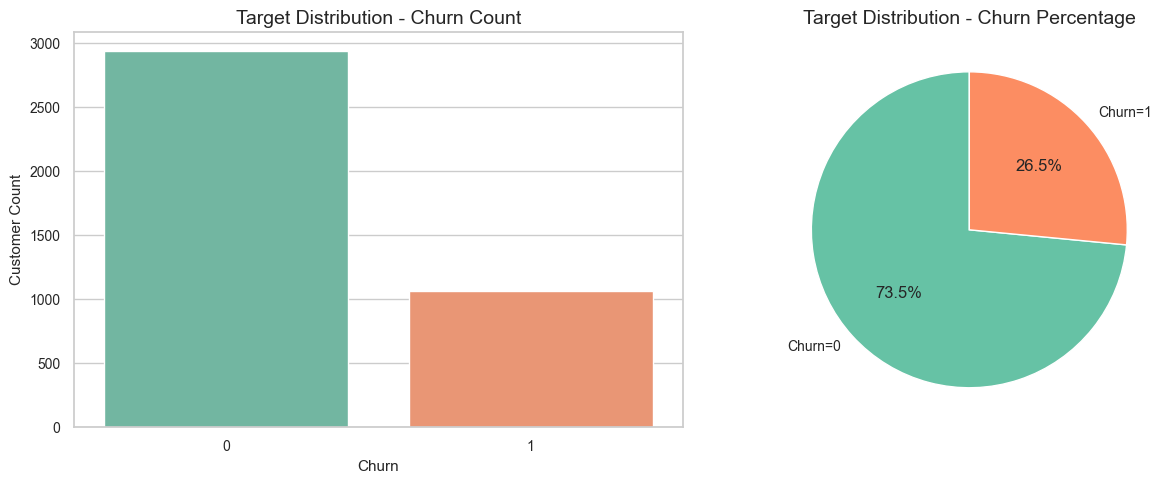

Overall churn rate: 26.52%
Nhận xét: churn nằm khoảng 20-30%, dataset có imbalance nhẹ/vừa. Notebook này chỉ ghi nhận, chưa xử lý imbalance.


In [72]:
if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found in dataset.")

target_counts = df[TARGET_COL].value_counts(dropna=False).sort_index()
target_percent = df[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index() * 100
target_table = pd.DataFrame({
    "Churn value": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percent.values.round(2),
})
display(target_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x=TARGET_COL, ax=axes[0], palette="Set2")
axes[0].set_title("Target Distribution - Churn Count")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Customer Count")

axes[1].pie(
    target_counts.values,
    labels=[f"Churn={idx}" for idx in target_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", n_colors=len(target_counts)),
)
axes[1].set_title("Target Distribution - Churn Percentage")
axes[1].set_ylabel("")

plt.tight_layout()
save_fig("target_churn_distribution.png")
plt.show()

churn_rate_overall = df[TARGET_COL].mean() * 100
print(f"Overall churn rate: {churn_rate_overall:.2f}%")
if 20 <= churn_rate_overall <= 30:
    print("Nhận xét: churn nằm khoảng 20-30%, dataset có imbalance nhẹ/vừa. Notebook này chỉ ghi nhận, chưa xử lý imbalance.")
elif churn_rate_overall < 20:
    print("Nhận xét: tỷ lệ churn tương đối thấp. Notebook này chỉ ghi nhận, chưa xử lý imbalance.")
else:
    print("Nhận xét: tỷ lệ churn tương đối cao hoặc imbalance đáng chú ý. Notebook này chỉ ghi nhận, chưa xử lý imbalance.")


## 7. Define feature groups

Chia feature thành các nhóm binary, discrete/ordinal và continuous numeric. Nếu thiếu cột, notebook sẽ bỏ qua an toàn và in warning.


In [73]:
binary_features = safe_existing_columns([
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Group_visits",
])

discrete_features = safe_existing_columns([
    "Contract_period",
    "Month_to_end_contract",
])

continuous_features = safe_existing_columns([
    "Age",
    "Avg_additional_charges_total",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
])

binary_discrete_features = safe_existing_columns(binary_features + discrete_features)

print("Binary features:", binary_features)
print("Discrete / ordinal features:", discrete_features)
print("Continuous numeric features:", continuous_features)
print("Target:", TARGET_COL)


Binary features: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits']
Discrete / ordinal features: ['Contract_period', 'Month_to_end_contract']
Continuous numeric features: ['Age', 'Avg_additional_charges_total', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
Target: Churn


## 8. Univariate analysis

Phân tích từng feature riêng lẻ. Với binary/discrete feature, xem countplot và bảng tỷ lệ. Với continuous feature, xem histogram + KDE, boxplot, skewness và nhận xét phân phối.


Univariate analysis for gender


,value,count,percentage
0,0,1959,48.9800
1,1,2041,51.0200


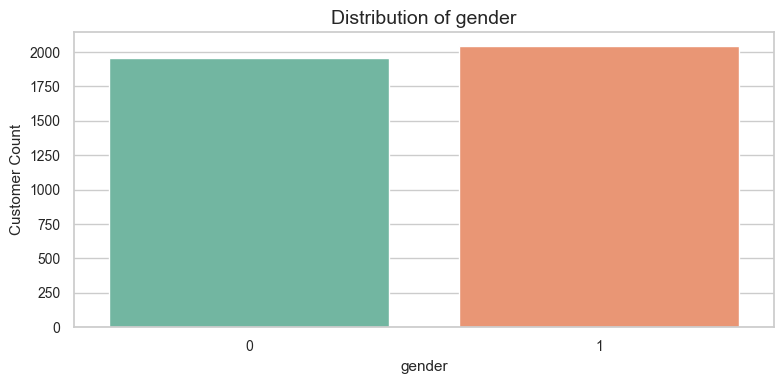

Univariate analysis for Near_Location


,value,count,percentage
0,0,619,15.4800
1,1,3381,84.5200


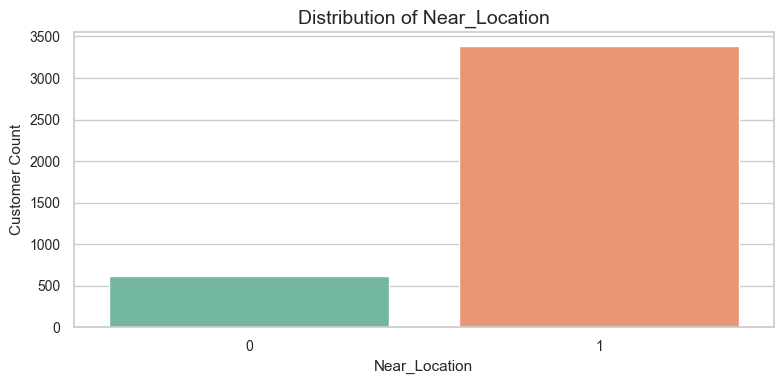

Univariate analysis for Partner


,value,count,percentage
0,0,2053,51.3200
1,1,1947,48.6800


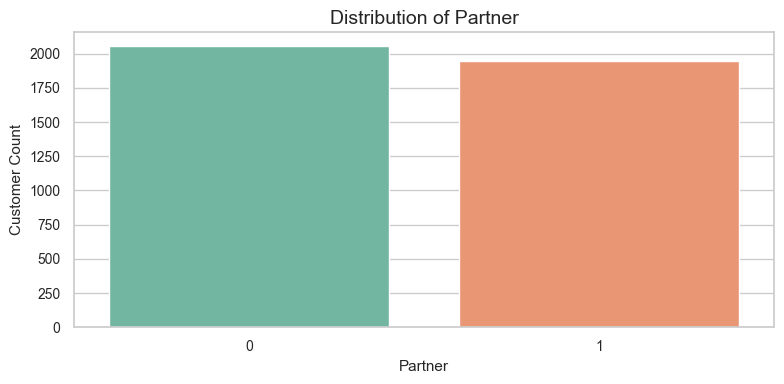

Univariate analysis for Promo_friends


,value,count,percentage
0,0,2766,69.1500
1,1,1234,30.8500


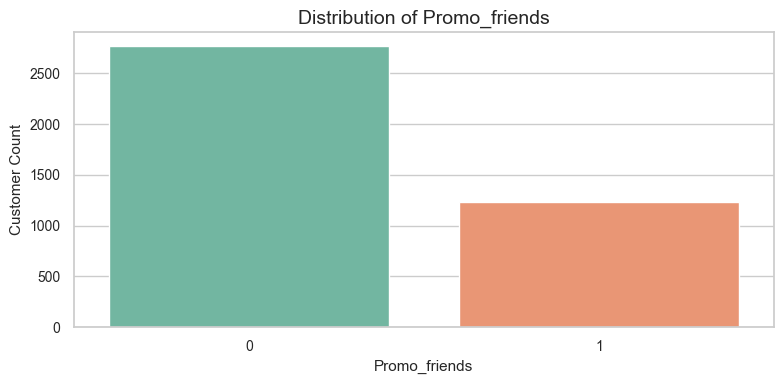

Univariate analysis for Phone


,value,count,percentage
0,0,386,9.6500
1,1,3614,90.3500


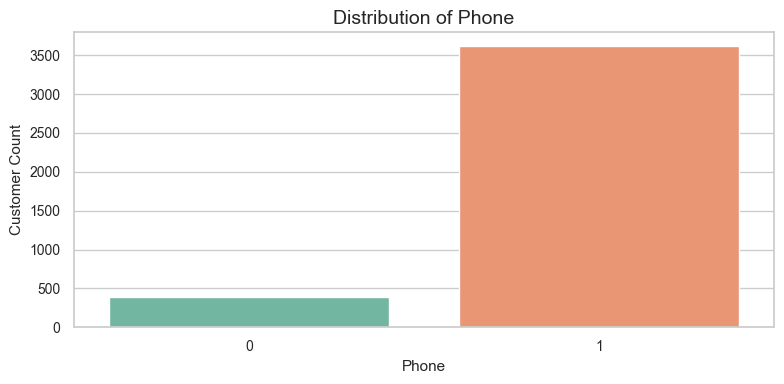

Univariate analysis for Group_visits


,value,count,percentage
0,0,2351,58.7800
1,1,1649,41.2200


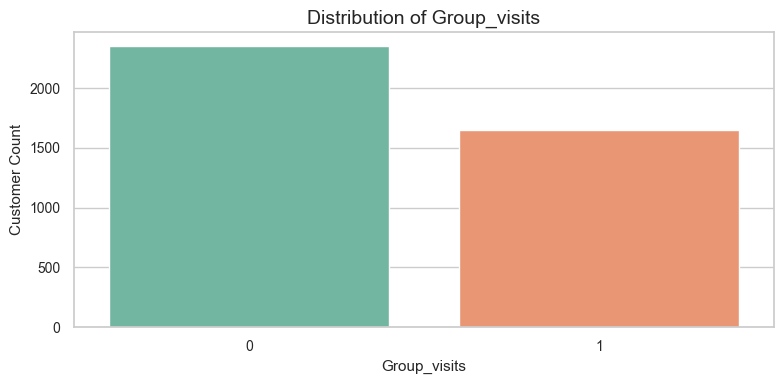

Univariate analysis for Contract_period


,value,count,percentage
0,1,2207,55.1800
1,6,833,20.8200
2,12,960,24.0000


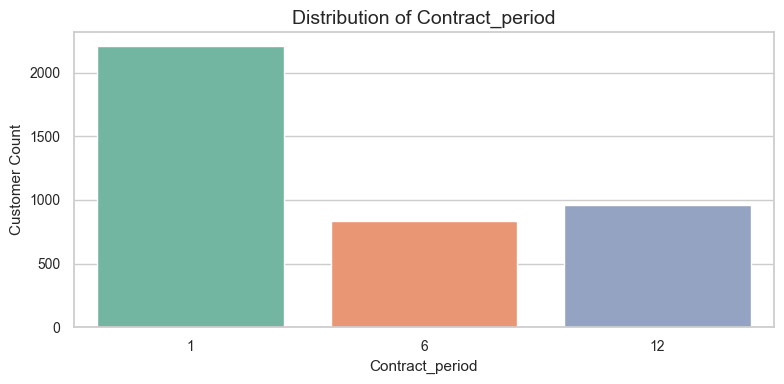

Univariate analysis for Month_to_end_contract


,value,count,percentage
0,1.0000,2207,55.1800
1,2.0000,14,0.3500
2,3.0000,23,0.5700
3,4.0000,58,1.4500
4,5.0000,130,3.2500
5,6.0000,645,16.1200
6,7.0000,25,0.6200
7,8.0000,38,0.9500
8,9.0000,73,1.8200
9,10.0000,82,2.0500


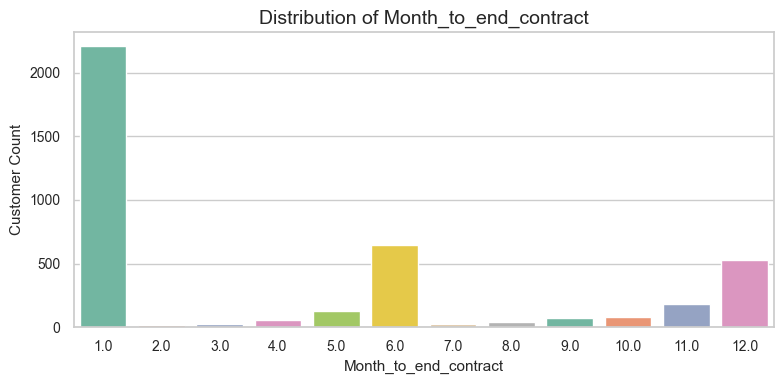

In [74]:
def display_value_counts(data: pd.DataFrame, col: str) -> pd.DataFrame:
    counts = data[col].value_counts(dropna=False).sort_index()
    percent = data[col].value_counts(normalize=True, dropna=False).sort_index() * 100
    table = pd.DataFrame({"value": counts.index, "count": counts.values, "percentage": percent.values.round(2)})
    display(table)
    return table

for col in binary_discrete_features:
    print("=" * 80)
    print(f"Univariate analysis for {col}")
    display_value_counts(df, col)

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, palette="Set2")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Customer Count")
    plt.tight_layout()
    if col in ["Contract_period", "Month_to_end_contract"]:
        save_fig(f"univariate_{col}_countplot.png")
    plt.show()


Univariate analysis for Age


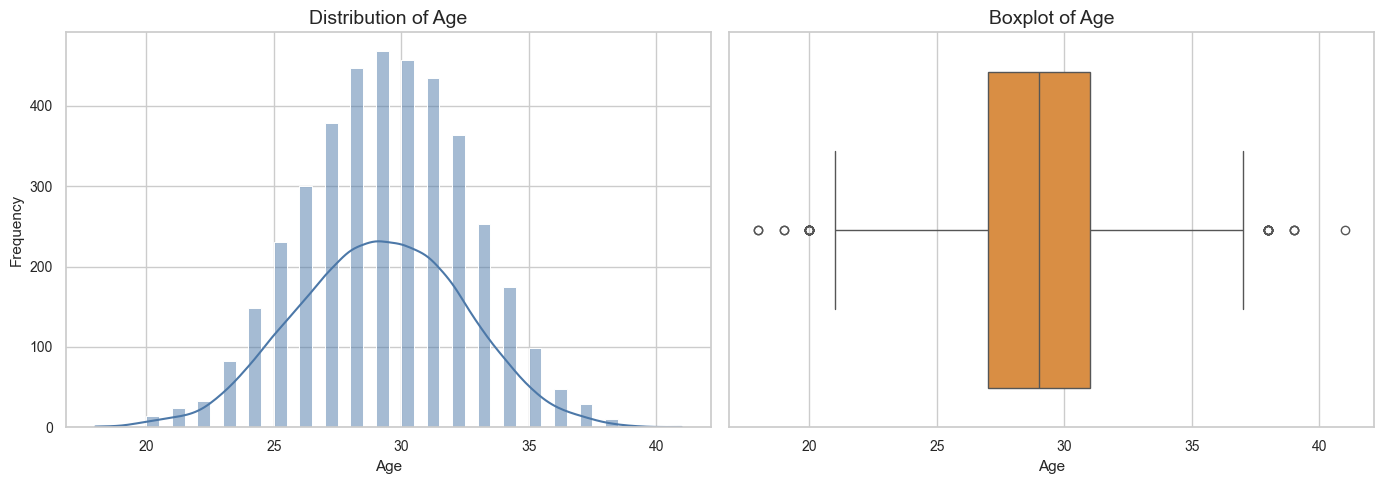

Skewness of Age: -0.0603. Phân phối tương đối cân bằng.
Univariate analysis for Avg_additional_charges_total


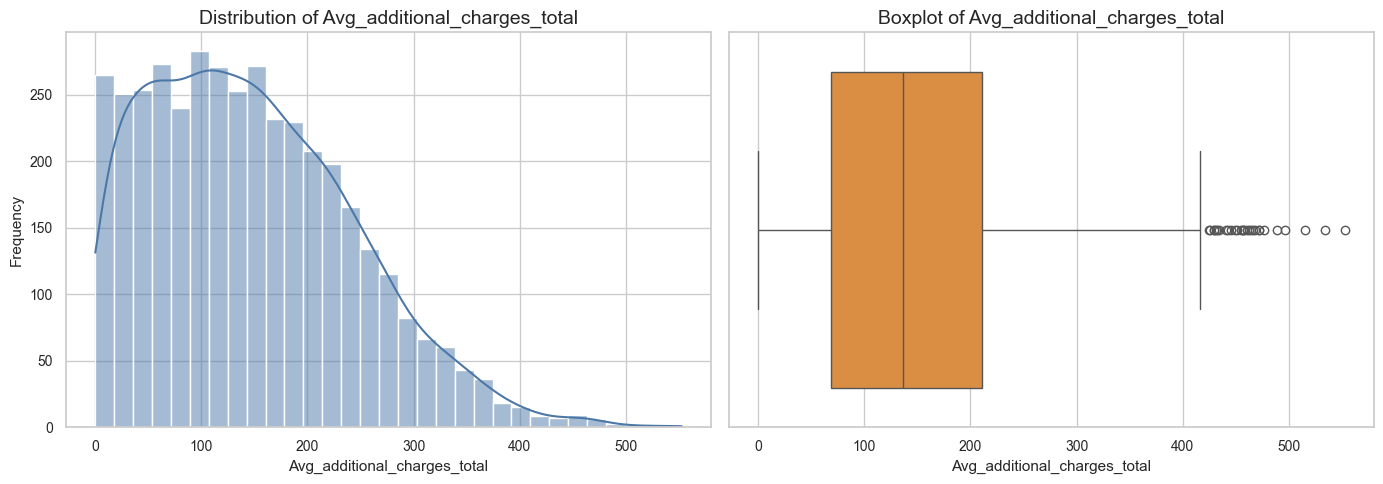

Skewness of Avg_additional_charges_total: 0.6169. Phân phối lệch phải.
Univariate analysis for Lifetime


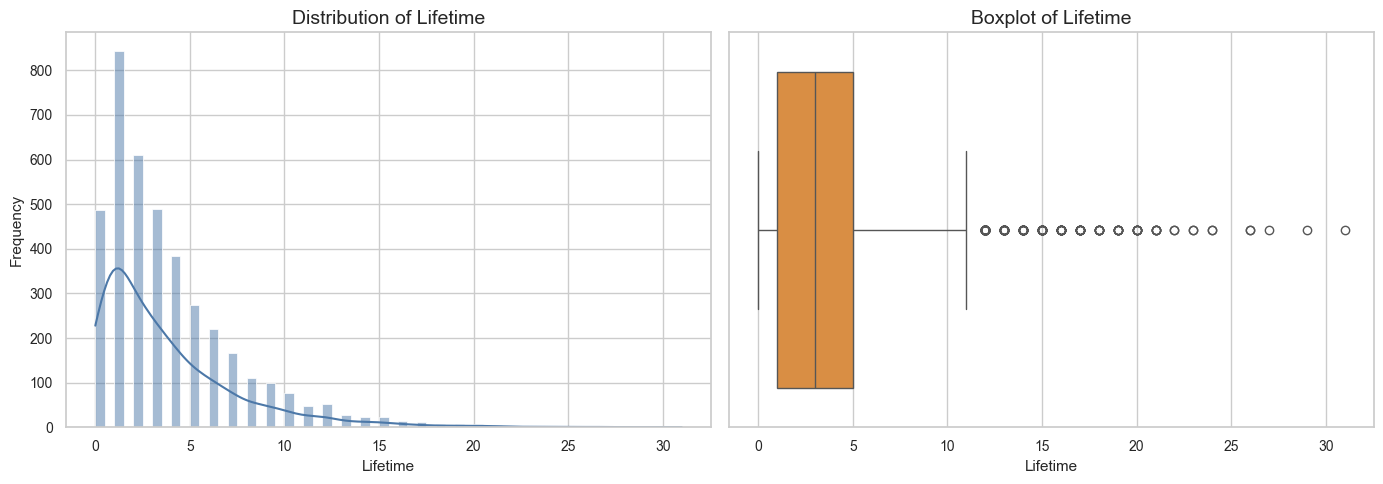

Skewness of Lifetime: 1.9275. Phân phối lệch phải.
Univariate analysis for Avg_class_frequency_total


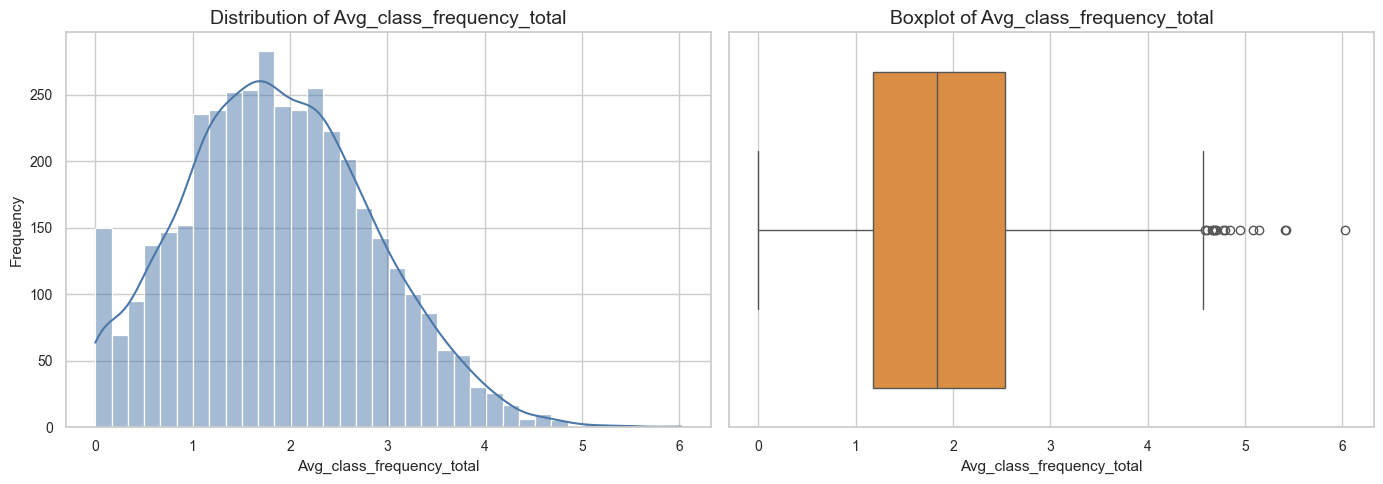

Skewness of Avg_class_frequency_total: 0.2530. Phân phối tương đối cân bằng.
Univariate analysis for Avg_class_frequency_current_month


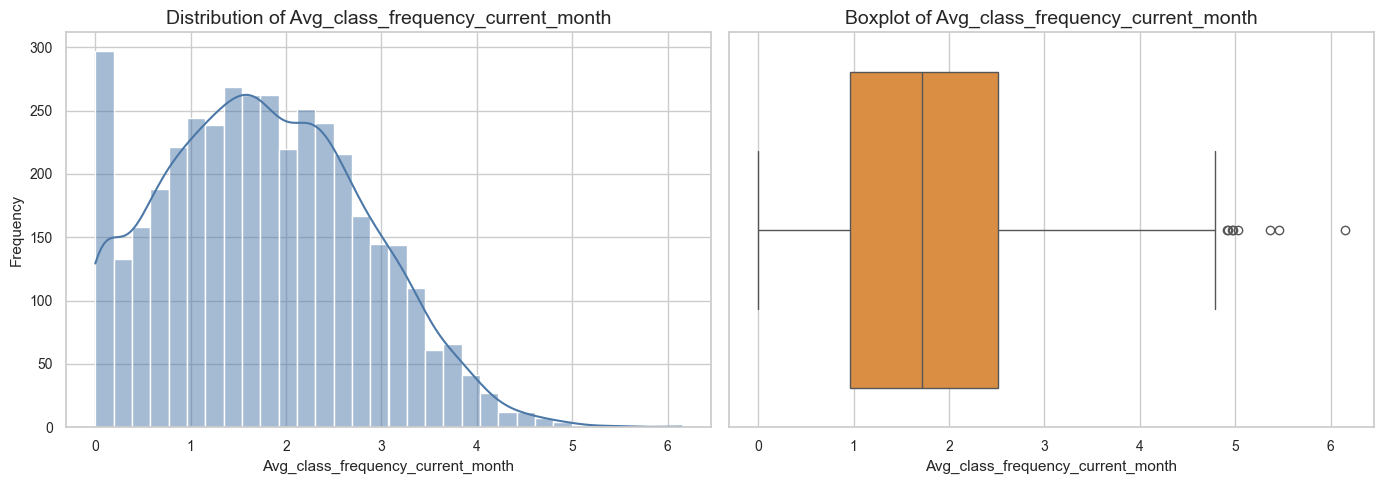

Skewness of Avg_class_frequency_current_month: 0.2621. Phân phối tương đối cân bằng.


In [75]:
def skewness_comment(skew_value: float) -> str:
    if skew_value > 0.5:
        return "Phân phối lệch phải."
    if skew_value < -0.5:
        return "Phân phối lệch trái."
    return "Phân phối tương đối cân bằng."

for col in continuous_features:
    print("=" * 80)
    print(f"Univariate analysis for {col}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color="#4C78A8")
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    sns.boxplot(x=df[col], ax=axes[1], color="#F28E2B")
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("")

    plt.tight_layout()
    save_fig(f"univariate_{col}_hist_box.png")
    plt.show()

    skew_value = df[col].skew()
    print(f"Skewness of {col}: {skew_value:.4f}. {skewness_comment(skew_value)}")


## 9. Bivariate analysis with Churn

Phần này phân tích mối quan hệ giữa từng feature với target `Churn`.


### 9.1 Binary/discrete features vs Churn

Với từng cột binary/discrete, notebook vẽ countplot theo `Churn`, tính churn rate theo từng giá trị feature, và sắp xếp các nhóm có churn rate cao.


gender vs Churn


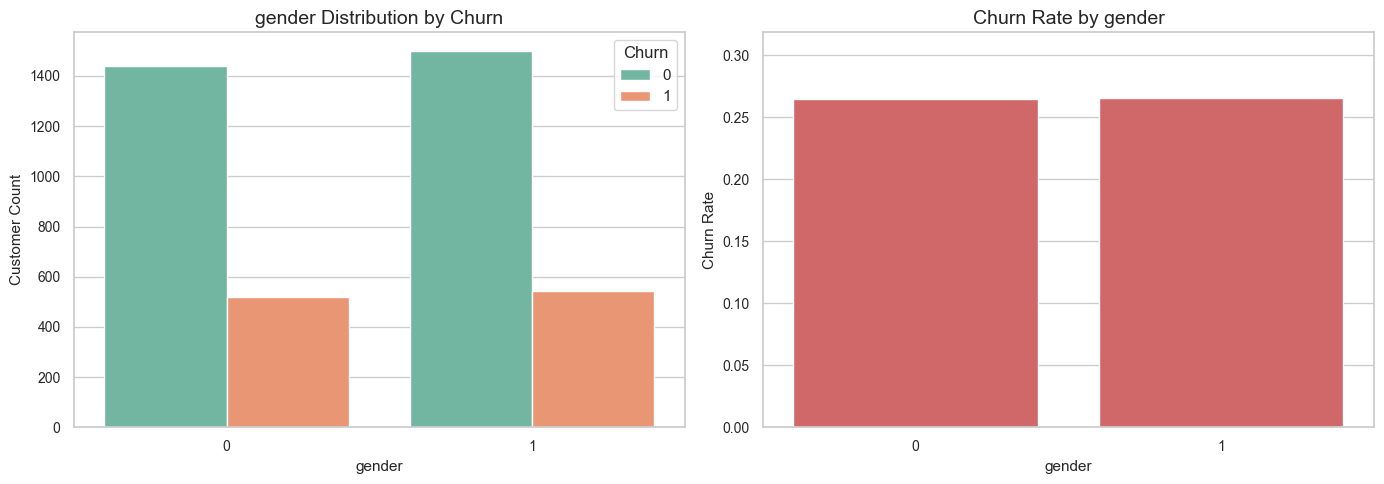

,feature_value,customer_count,churn_count,churn_rate
1,1,2041,542,0.2656
0,0,1959,519,0.2649


Near_Location vs Churn


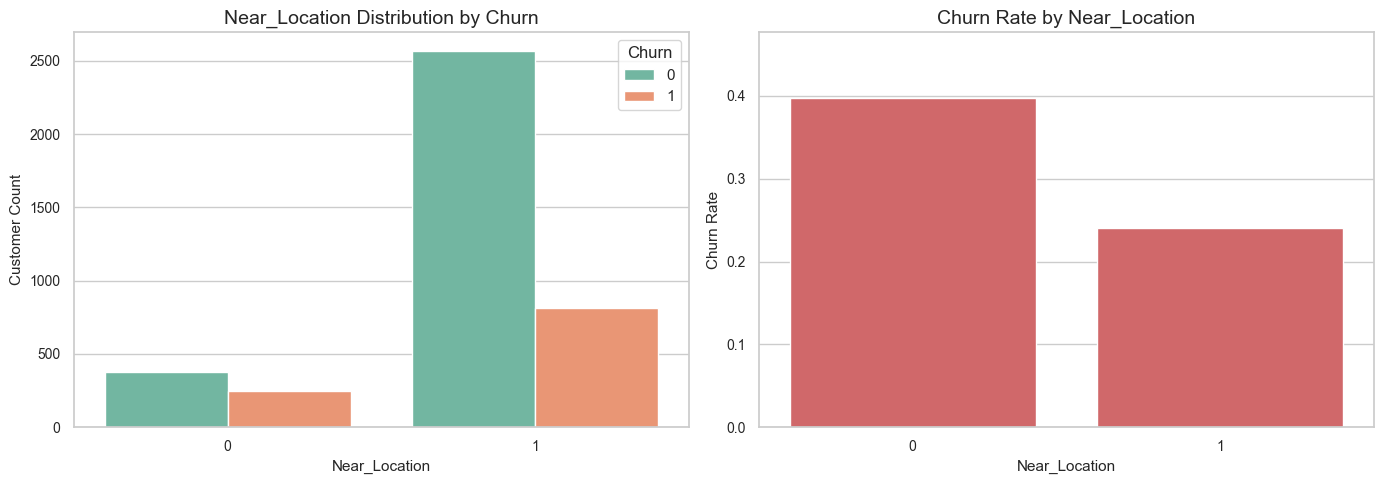

,feature_value,customer_count,churn_count,churn_rate
0,0,619,246,0.3974
1,1,3381,815,0.2411


Partner vs Churn


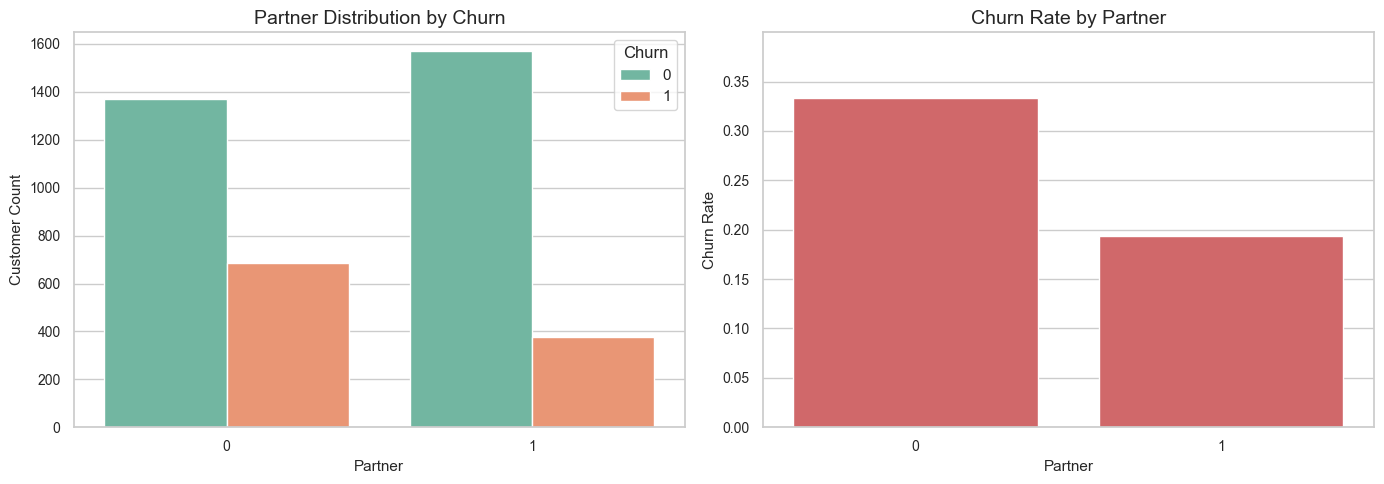

,feature_value,customer_count,churn_count,churn_rate
0,0,2053,684,0.3332
1,1,1947,377,0.1936


Promo_friends vs Churn


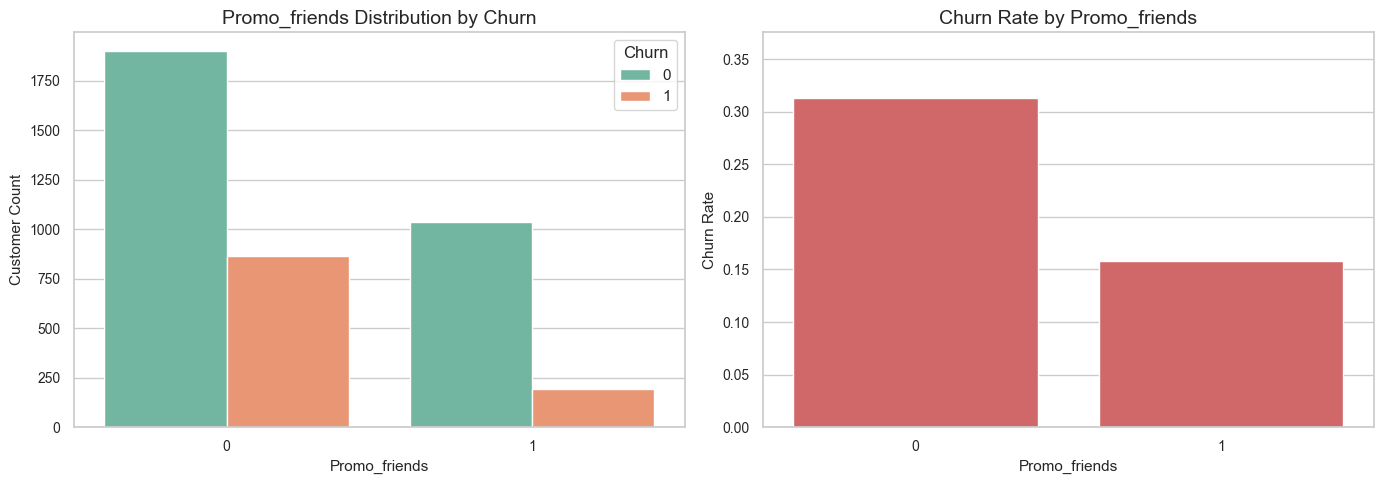

,feature_value,customer_count,churn_count,churn_rate
0,0,2766,866,0.3131
1,1,1234,195,0.1580


Phone vs Churn


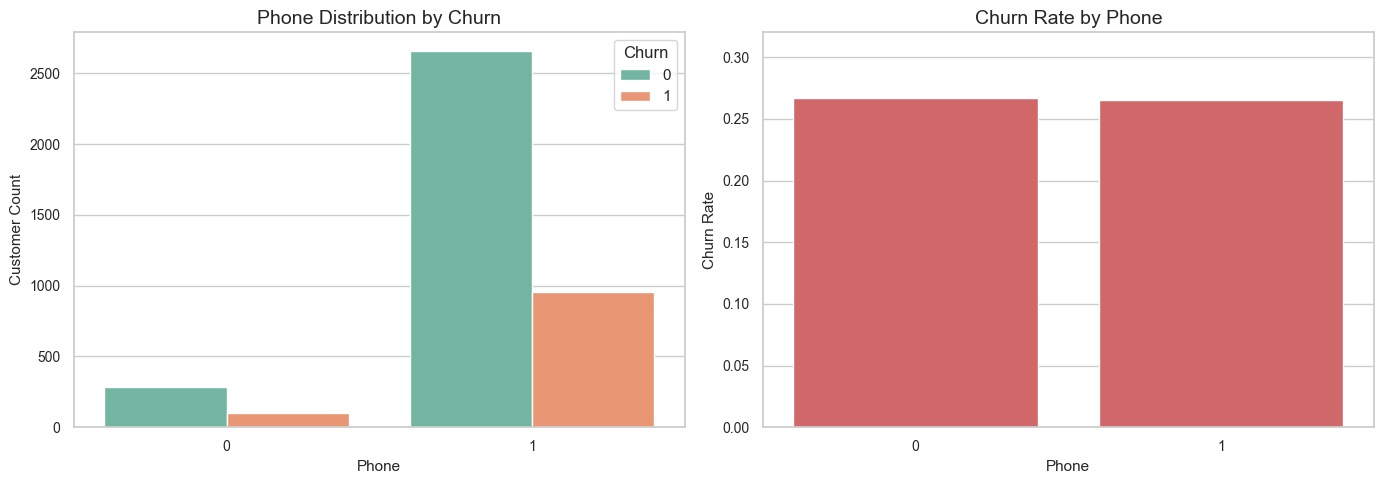

,feature_value,customer_count,churn_count,churn_rate
0,0,386,103,0.2668
1,1,3614,958,0.2651


Contract_period vs Churn


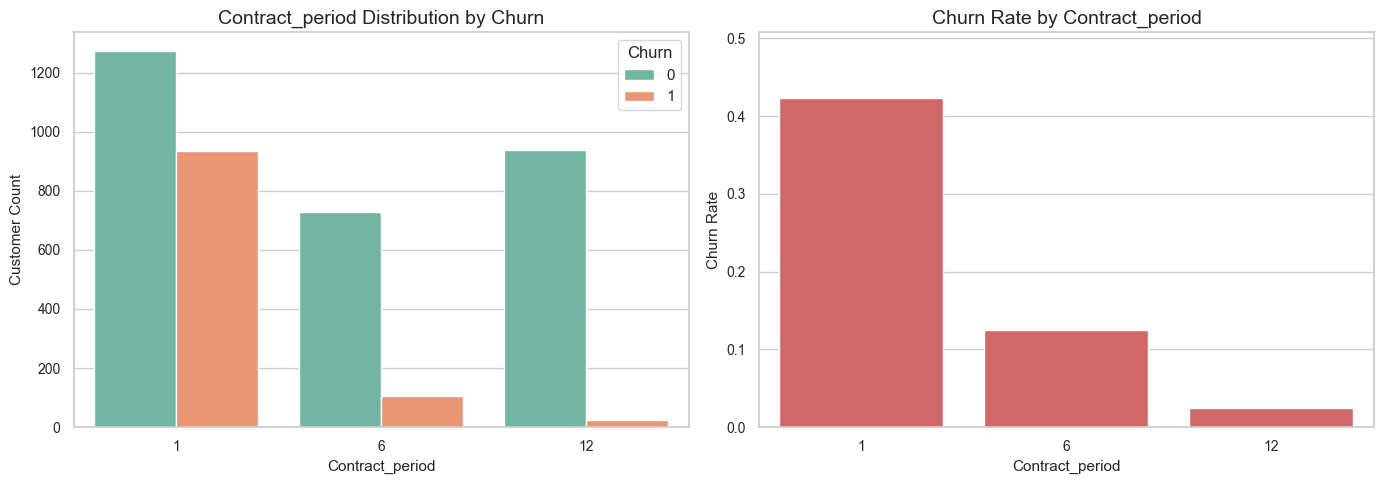

,feature_value,customer_count,churn_count,churn_rate
0,1,2207,934,0.4232
1,6,833,104,0.1248
2,12,960,23,0.0240


Group_visits vs Churn


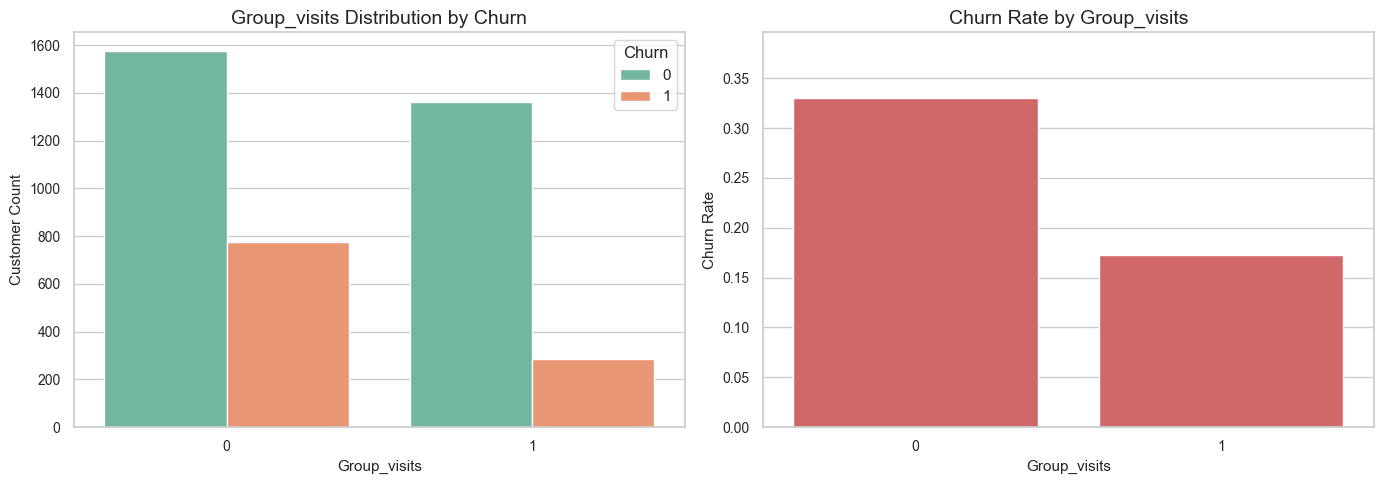

,feature_value,customer_count,churn_count,churn_rate
0,0,2351,776,0.3301
1,1,1649,285,0.1728


Month_to_end_contract vs Churn


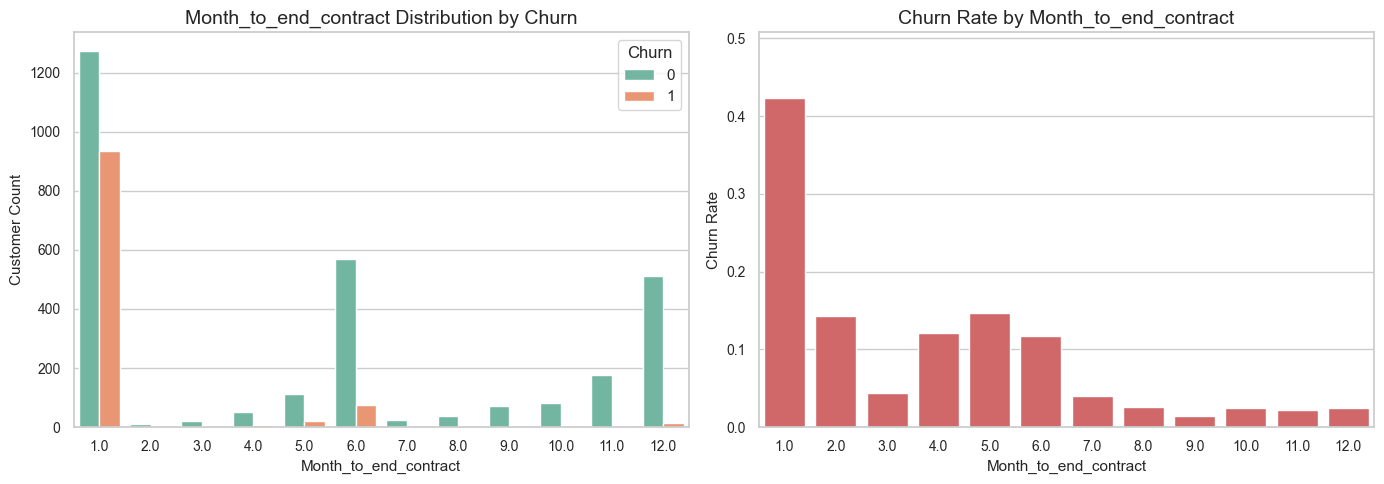

,feature_value,customer_count,churn_count,churn_rate
0,1.0000,2207,934,0.4232
4,5.0000,130,19,0.1462
1,2.0000,14,2,0.1429
3,4.0000,58,7,0.1207
5,6.0000,645,76,0.1178
2,3.0000,23,1,0.0435
6,7.0000,25,1,0.0400
7,8.0000,38,1,0.0263
11,12.0000,524,13,0.0248
9,10.0000,82,2,0.0244


In [76]:
bivariate_discrete_features = safe_existing_columns([
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Contract_period",
    "Group_visits",
    "Month_to_end_contract",
])

churn_rate_tables = {}
for col in bivariate_discrete_features:
    print("=" * 80)
    print(f"{col} vs {TARGET_COL}")
    tbl = plot_count_with_churn(df, col, TARGET_COL, save_prefix="bivariate")
    churn_rate_tables[col] = tbl
    display(tbl)


#### Kiểm tra giả thuyết: khách hàng không để lại số điện thoại có churn cao hơn không?

Logic kết luận:
- Nếu `Phone=0` có churn rate cao hơn `Phone=1`, giả thuyết được dữ liệu ủng hộ.
- Nếu không, giả thuyết chưa được dữ liệu ủng hộ.


In [77]:
if "Phone" in df.columns:
    phone_churn = churn_rate_table(df, "Phone", TARGET_COL)
    display(phone_churn)

    phone_rates = dict(zip(phone_churn["feature_value"], phone_churn["churn_rate"]))
    rate_phone_0 = phone_rates.get(0, np.nan)
    rate_phone_1 = phone_rates.get(1, np.nan)

    print(f"Churn rate when Phone=0: {rate_phone_0:.4f}")
    print(f"Churn rate when Phone=1: {rate_phone_1:.4f}")

    if pd.notna(rate_phone_0) and pd.notna(rate_phone_1):
        if rate_phone_0 > rate_phone_1:
            print("Kết luận: Giả thuyết được ủng hộ. Khách hàng không để lại số điện thoại có churn rate cao hơn.")
        else:
            print("Kết luận: Giả thuyết chưa được ủng hộ bởi dữ liệu. Phone=0 không có churn rate cao hơn Phone=1.")
else:
    print("Warning: Phone column not found; hypothesis skipped.")


,feature_value,customer_count,churn_count,churn_rate
0,0,386,103,0.2668
1,1,3614,958,0.2651


Churn rate when Phone=0: 0.2668
Churn rate when Phone=1: 0.2651
Kết luận: Giả thuyết được ủng hộ. Khách hàng không để lại số điện thoại có churn rate cao hơn.


### 9.2 Continuous numeric features vs Churn

Với từng numeric continuous feature, notebook so sánh phân phối theo nhóm churn/non-churn bằng boxplot và KDE/violin, đồng thời tính mean, median, std.


Age vs Churn


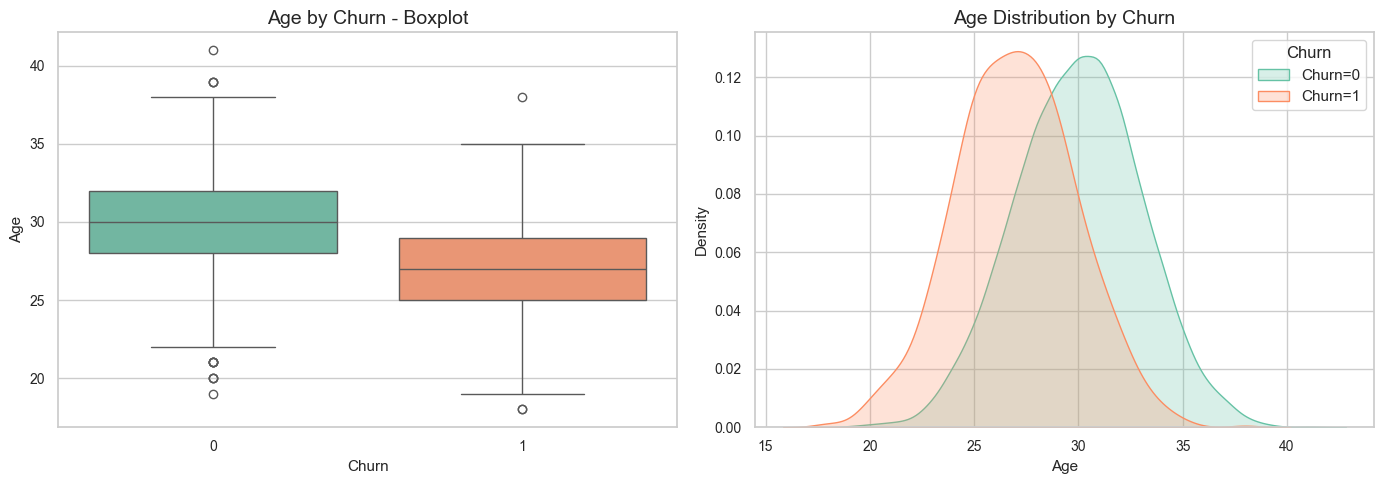

,mean,median,std,count
Churn,,,,
0,29.9765,30.0000,3.0099,2939
1,26.9896,27.0000,2.8952,1061


Avg_additional_charges_total vs Churn


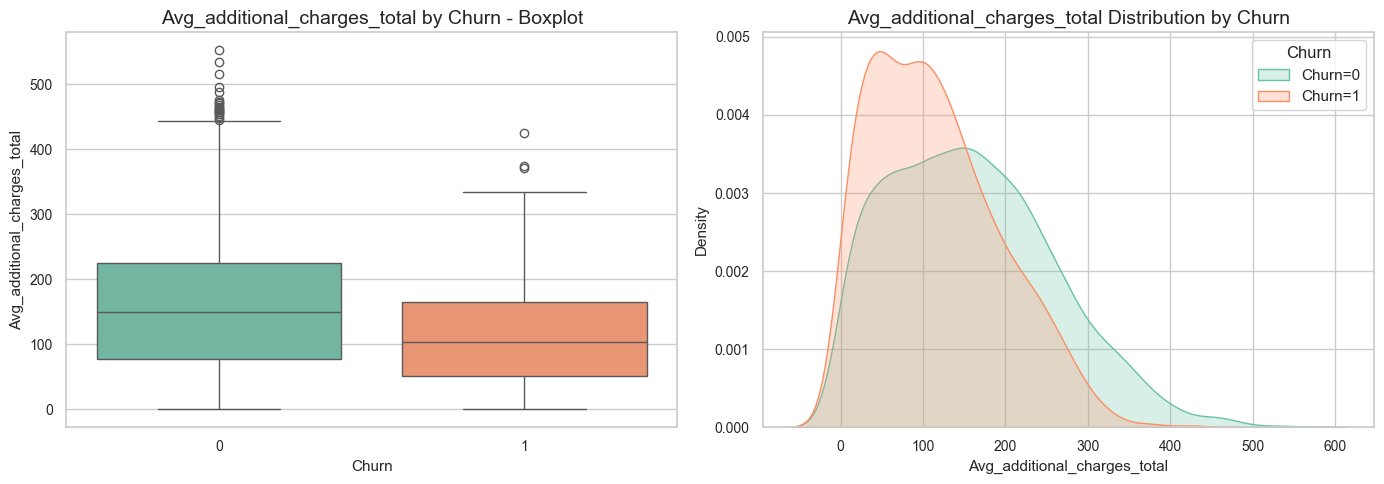

,mean,median,std,count
Churn,,,,
0,158.4457,149.8812,99.8016,2939
1,115.0829,103.8147,77.6964,1061


Lifetime vs Churn


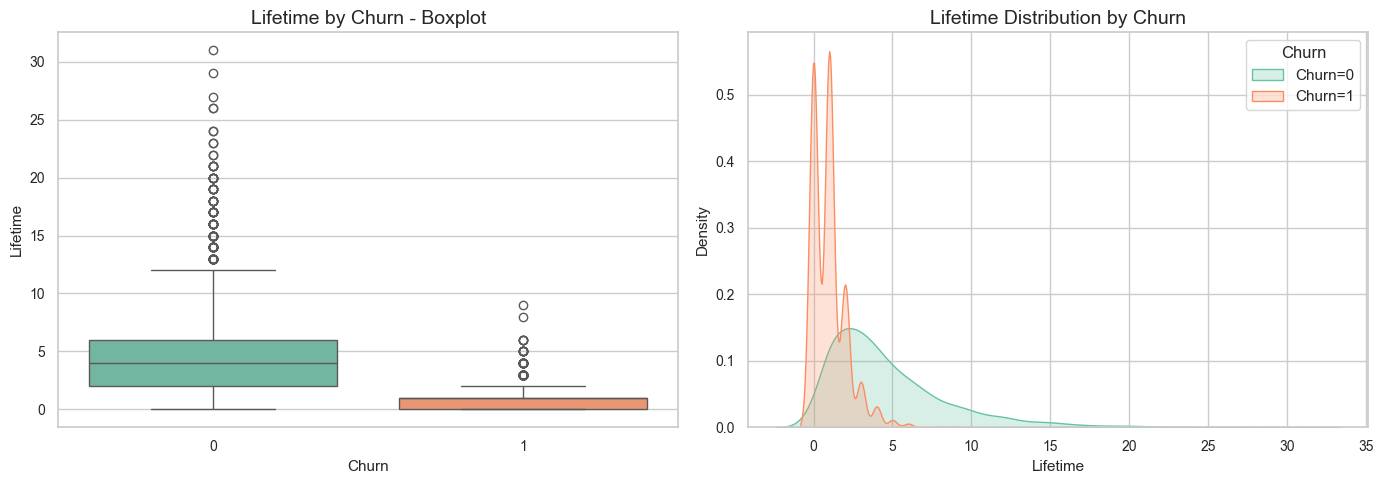

,mean,median,std,count
Churn,,,,
0,4.7118,4.0000,3.8748,2939
1,0.9906,1.0000,1.1108,1061


Avg_class_frequency_total vs Churn


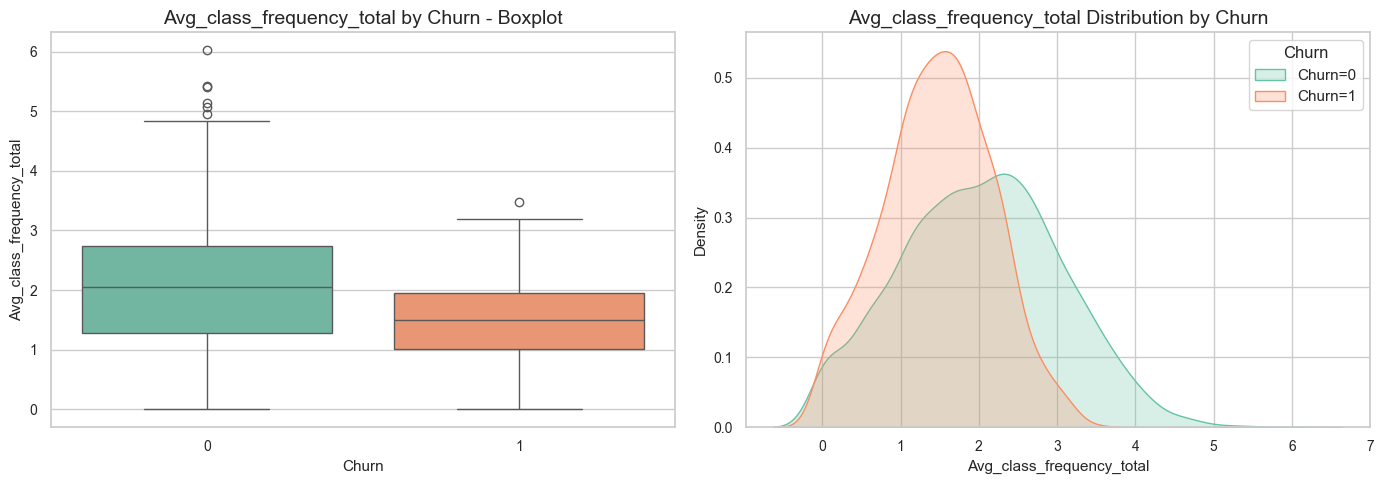

,mean,median,std,count
Churn,,,,
0,2.0249,2.0433,1.0160,2939
1,1.4750,1.4912,0.6947,1061


Avg_class_frequency_current_month vs Churn


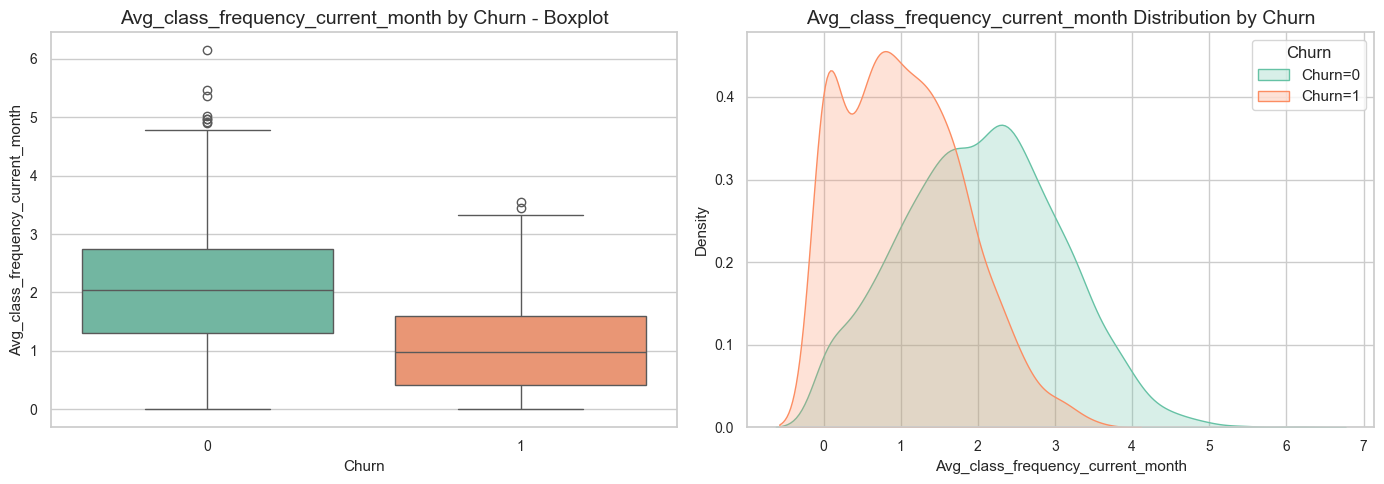

,mean,median,std,count
Churn,,,,
0,2.0279,2.0467,1.0190,2939
1,1.0445,0.9794,0.7702,1061


,feature,mean_non_churn,mean_churn,median_non_churn,median_churn,difference
0,Age,29.9765,26.9896,30.0000,27.0000,-2.9869
1,Avg_additional_charges_total,158.4457,115.0829,149.8812,103.8147,-43.3628
2,Lifetime,4.7118,0.9906,4.0000,1.0000,-3.7212
3,Avg_class_frequency_total,2.0249,1.4750,2.0433,1.4912,-0.5499
4,Avg_class_frequency_current_month,2.0279,1.0445,2.0467,0.9794,-0.9833


In [78]:
numeric_comparison_rows = []

for col in continuous_features:
    print("=" * 80)
    print(f"{col} vs {TARGET_COL}")
    summary = plot_numeric_by_churn(df, col, TARGET_COL, save_prefix="bivariate_numeric")
    display(summary)

    if set([0, 1]).issubset(set(summary.index)):
        numeric_comparison_rows.append({
            "feature": col,
            "mean_non_churn": summary.loc[0, "mean"],
            "mean_churn": summary.loc[1, "mean"],
            "median_non_churn": summary.loc[0, "median"],
            "median_churn": summary.loc[1, "median"],
            "difference": summary.loc[1, "mean"] - summary.loc[0, "mean"],
        })

numeric_churn_comparison = pd.DataFrame(numeric_comparison_rows)
display(numeric_churn_comparison)


## 10. Churn rate ranking

Tạo bảng tổng hợp churn rate cho tất cả binary/discrete features, lọc nhóm có ít nhất 30 khách hàng để tránh nhóm quá nhỏ, sau đó hiển thị top 15 nhóm rủi ro cao nhất.


,feature,value,customer_count,churn_rate,feature_value_label
12,Contract_period,1,2207,0.4232,Contract_period=1
15,Month_to_end_contract,1.0,2207,0.4232,Month_to_end_contract=1.0
2,Near_Location,0,619,0.3974,Near_Location=0
4,Partner,0,2053,0.3332,Partner=0
10,Group_visits,0,2351,0.3301,Group_visits=0
6,Promo_friends,0,2766,0.3131,Promo_friends=0
8,Phone,0,386,0.2668,Phone=0
0,gender,1,2041,0.2656,gender=1
9,Phone,1,3614,0.2651,Phone=1
1,gender,0,1959,0.2649,gender=0


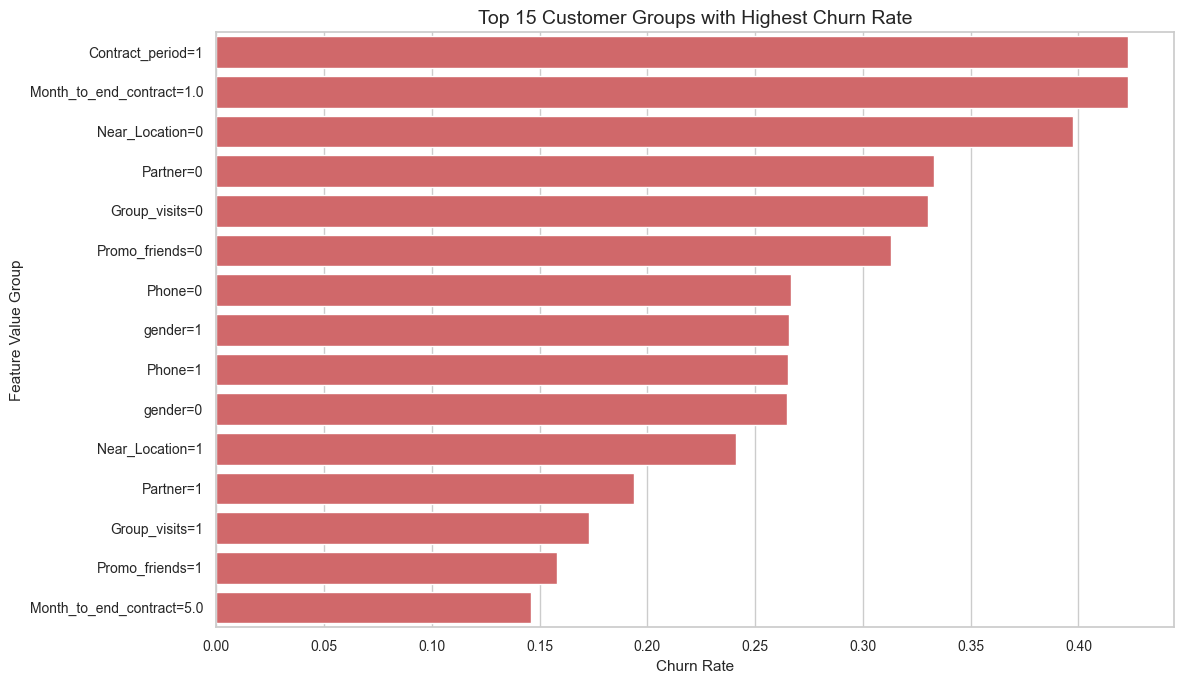

In [79]:
ranking_rows = []
for col in binary_discrete_features:
    tbl = churn_rate_table(df, col, TARGET_COL)
    if tbl.empty:
        continue
    tbl = tbl.copy()
    tbl["feature"] = col
    tbl["value"] = tbl["feature_value"].astype(str)
    ranking_rows.append(tbl[["feature", "value", "customer_count", "churn_rate"]])

if ranking_rows:
    churn_ranking = pd.concat(ranking_rows, ignore_index=True)
    churn_ranking_filtered = churn_ranking[churn_ranking["customer_count"] >= 30].copy()
    top15_churn_groups = churn_ranking_filtered.sort_values("churn_rate", ascending=False).head(15)
    top15_churn_groups["feature_value_label"] = top15_churn_groups["feature"] + "=" + top15_churn_groups["value"]

    display(top15_churn_groups)

    plt.figure(figsize=(12, 7))
    sns.barplot(data=top15_churn_groups, y="feature_value_label", x="churn_rate", color="#E15759")
    plt.title("Top 15 Customer Groups with Highest Churn Rate")
    plt.xlabel("Churn Rate")
    plt.ylabel("Feature Value Group")
    plt.tight_layout()
    save_fig("top15_highest_churn_rate_groups.png")
    plt.show()
else:
    print("No binary/discrete features available for churn rate ranking.")


## 11. Correlation and Association Heatmaps

Dataset có cả biến liên tục, biến binary và biến rời rạc/ordinal, vì vậy không nên dùng một Pearson heatmap duy nhất cho toàn bộ numeric columns. Phần này tách thành 2 heatmap:

1. **Heatmap 1 - Continuous features:** dùng Spearman correlation cho các biến liên tục vì Spearman phù hợp hơn khi phân phối lệch hoặc quan hệ không hoàn toàn tuyến tính.
2. **Heatmap 2 - Discrete features:** dùng Chi-square test để đo association giữa các biến rời rạc/binary, sau đó biểu diễn bằng **Cramér's V**. Cramér's V nằm trong khoảng 0-1, càng cao nghĩa là association càng mạnh.

Lưu ý: correlation/association không chứng minh quan hệ nhân quả.


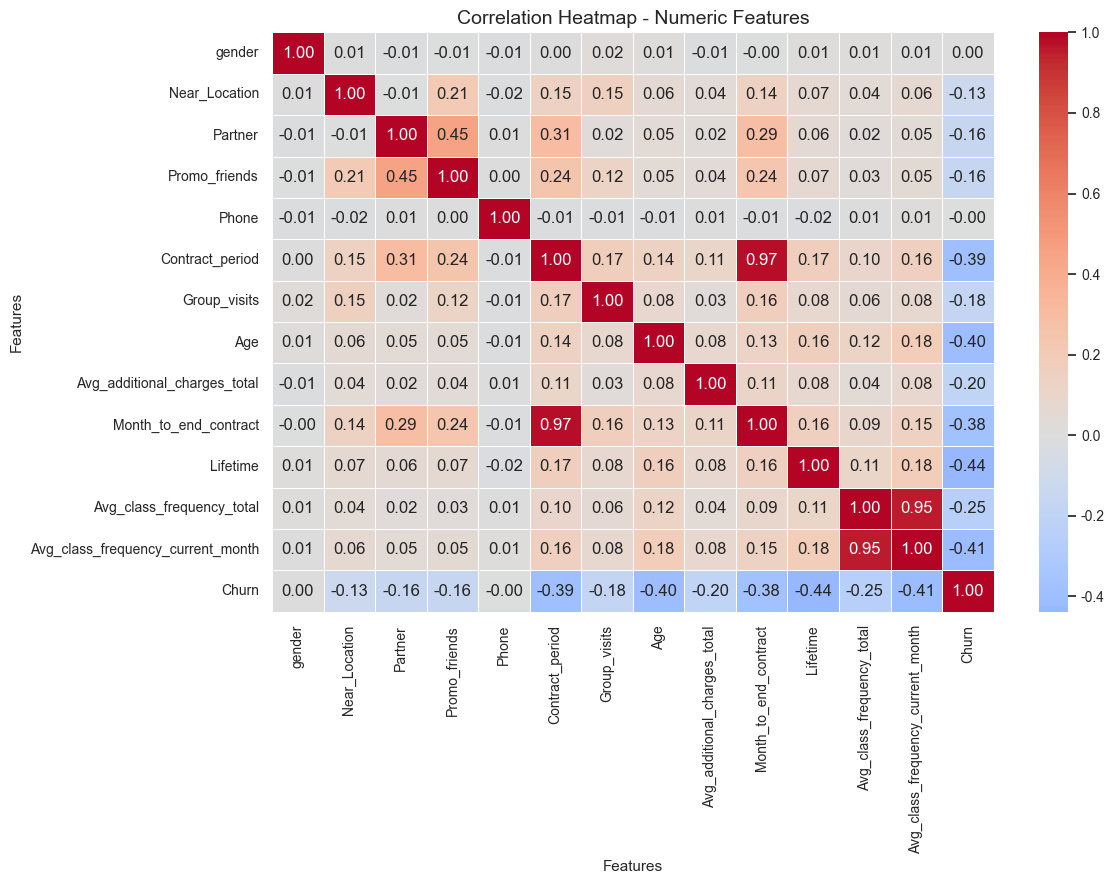

,feature,correlation_with_churn,abs_correlation
10,Lifetime,-0.4382,0.4382
12,Avg_class_frequency_current_month,-0.4123,0.4123
7,Age,-0.4047,0.4047
5,Contract_period,-0.3900,0.3900
9,Month_to_end_contract,-0.3814,0.3814
11,Avg_class_frequency_total,-0.2497,0.2497
8,Avg_additional_charges_total,-0.1987,0.1987
6,Group_visits,-0.1753,0.1753
3,Promo_friends,-0.1622,0.1622
2,Partner,-0.1580,0.1580


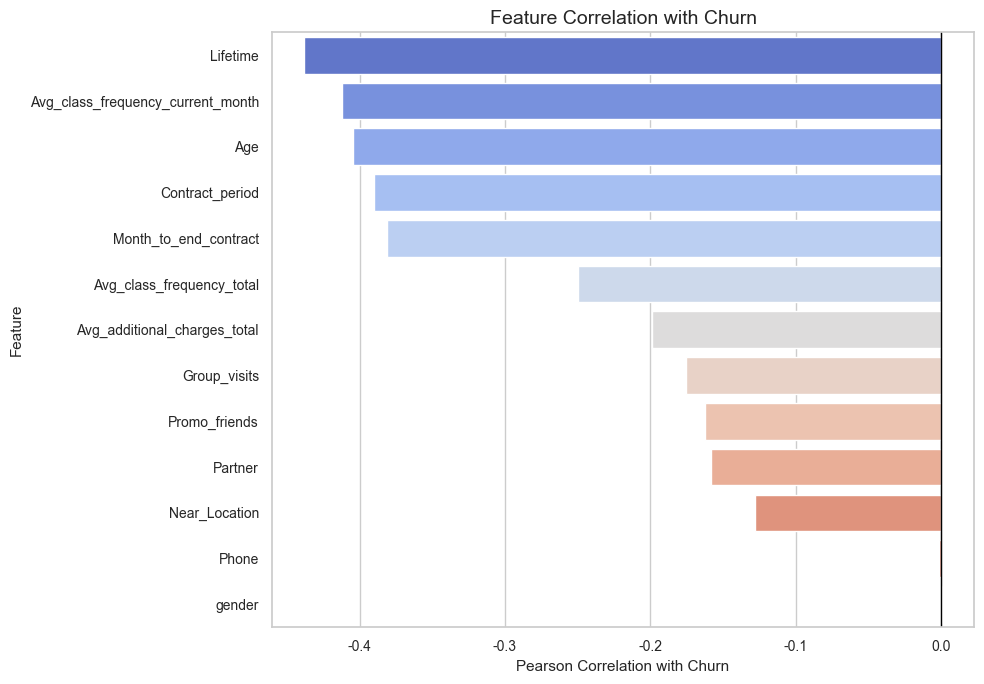

In [80]:
# Continuous features: Spearman correlation heatmap
continuous_for_corr = safe_existing_columns([
    "Age",
    "Avg_additional_charges_total",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
])

if len(continuous_for_corr) >= 2:
    continuous_corr_matrix = df[continuous_for_corr].corr(method="spearman")

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        continuous_corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        square=True,
    )
    plt.title("Heatmap 1 - Spearman Correlation Matrix for Continuous Features")
    plt.xlabel("Continuous Features")
    plt.ylabel("Continuous Features")
    plt.tight_layout()
    save_fig("continuous_features_spearman_correlation_heatmap.png")
    plt.show()
else:
    print("Not enough continuous features to draw Spearman correlation heatmap.")


# Discrete/binary features: Chi-square association heatmap using Cramér's V
try:
    from scipy.stats import chi2_contingency, pointbiserialr
except ImportError:
    chi2_contingency = None
    pointbiserialr = None
    print("scipy is not installed. Chi-square association heatmap will be skipped.")


def cramers_v(data: pd.DataFrame, col1: str, col2: str) -> float:
    """Calculate Cramér's V from Chi-square test for two categorical/discrete variables."""
    if chi2_contingency is None:
        return np.nan
    confusion = pd.crosstab(data[col1], data[col2])
    if confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return 0.0

    chi2, p_value, dof, expected = chi2_contingency(confusion)
    n = confusion.to_numpy().sum()
    if n == 0:
        return np.nan

    r, k = confusion.shape
    denominator = n * (min(k - 1, r - 1))
    if denominator == 0:
        return 0.0
    return np.sqrt(chi2 / denominator)


def chi_square_p_value(data: pd.DataFrame, col1: str, col2: str) -> float:
    """Return p-value from Chi-square test for two categorical/discrete variables."""
    if chi2_contingency is None:
        return np.nan
    confusion = pd.crosstab(data[col1], data[col2])
    if confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return np.nan
    chi2, p_value, dof, expected = chi2_contingency(confusion)
    return p_value


discrete_for_chi_square = safe_existing_columns([
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Group_visits",
    "Contract_period",
    "Month_to_end_contract",
    TARGET_COL,
])

if chi2_contingency is not None and len(discrete_for_chi_square) >= 2:
    cramers_v_matrix = pd.DataFrame(
        np.eye(len(discrete_for_chi_square)),
        index=discrete_for_chi_square,
        columns=discrete_for_chi_square,
    )
    chi_square_p_matrix = pd.DataFrame(
        np.nan,
        index=discrete_for_chi_square,
        columns=discrete_for_chi_square,
    )

    for i, col1 in enumerate(discrete_for_chi_square):
        for j, col2 in enumerate(discrete_for_chi_square):
            if i == j:
                cramers_v_matrix.loc[col1, col2] = 1.0
                chi_square_p_matrix.loc[col1, col2] = 0.0
            elif i < j:
                v_value = cramers_v(df, col1, col2)
                p_value = chi_square_p_value(df, col1, col2)
                cramers_v_matrix.loc[col1, col2] = v_value
                cramers_v_matrix.loc[col2, col1] = v_value
                chi_square_p_matrix.loc[col1, col2] = p_value
                chi_square_p_matrix.loc[col2, col1] = p_value

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cramers_v_matrix,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        square=True,
    )
    plt.title("Heatmap 2 - Chi-square Association for Discrete Features (Cramér's V)")
    plt.xlabel("Discrete / Binary Features")
    plt.ylabel("Discrete / Binary Features")
    plt.tight_layout()
    save_fig("discrete_features_chi_square_cramers_v_heatmap.png")
    plt.show()

    print("Chi-square p-value matrix for discrete/binary features:")
    display(chi_square_p_matrix)
else:
    print("Chi-square association heatmap skipped because scipy is unavailable or there are not enough discrete features.")


# Association with Churn summary
# Continuous vs binary target: point-biserial correlation.
# Discrete vs binary target: Cramér's V based on Chi-square test.
continuous_churn_rows = []
if TARGET_COL in df.columns and pointbiserialr is not None:
    for feature in continuous_for_corr:
        if df[feature].nunique(dropna=True) > 1:
            corr_value, p_value = pointbiserialr(df[TARGET_COL], df[feature])
            continuous_churn_rows.append({
                "feature": feature,
                "association_type": "point_biserial",
                "correlation_with_churn": corr_value,
                "abs_correlation": abs(corr_value),
                "p_value": p_value,
            })

churn_corr = pd.DataFrame(continuous_churn_rows).sort_values("abs_correlation", ascending=False)
if not churn_corr.empty:
    print("Continuous features association with Churn (point-biserial):")
    display(churn_corr)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=churn_corr, y="feature", x="correlation_with_churn", palette="coolwarm")
    plt.title("Continuous Feature Correlation with Churn")
    plt.xlabel("Point-biserial Correlation with Churn")
    plt.ylabel("Feature")
    plt.axvline(0, color="black", linewidth=1)
    plt.tight_layout()
    save_fig("continuous_feature_correlation_with_churn.png")
    plt.show()

discrete_churn_rows = []
if TARGET_COL in df.columns and chi2_contingency is not None:
    for feature in [col for col in discrete_for_chi_square if col != TARGET_COL]:
        discrete_churn_rows.append({
            "feature": feature,
            "association_type": "chi_square_cramers_v",
            "cramers_v_with_churn": cramers_v(df, feature, TARGET_COL),
            "p_value": chi_square_p_value(df, feature, TARGET_COL),
        })

discrete_churn_association = pd.DataFrame(discrete_churn_rows).sort_values("cramers_v_with_churn", ascending=False)
if not discrete_churn_association.empty:
    print("Discrete/binary features association with Churn (Chi-square + Cramér's V):")
    display(discrete_churn_association)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=discrete_churn_association, y="feature", x="cramers_v_with_churn", color="#4C78A8")
    plt.title("Discrete Feature Association with Churn - Cramér's V")
    plt.xlabel("Cramér's V with Churn")
    plt.ylabel("Feature")
    plt.xlim(0, 1)
    plt.tight_layout()
    save_fig("discrete_feature_cramers_v_with_churn.png")
    plt.show()


## 12. Hypothesis testing / business questions

Phần này kiểm tra các giả thuyết business bằng cách tạo nhóm đơn giản, so sánh churn rate và vẽ barplot. Đây là phân tích mô tả, không phải kiểm định nhân quả.


In [81]:
def compare_churn_for_group(data: pd.DataFrame, group_col: str, title: str, expected_direction: str | None = None) -> pd.DataFrame:
    """Display churn rate table and barplot for a grouping column."""
    if group_col not in data.columns:
        print(f"Warning: {group_col} not found; skipped.")
        return pd.DataFrame()

    tbl = churn_rate_table(data, group_col, TARGET_COL)
    display(tbl)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=tbl, x="feature_value", y="churn_rate", color="#E15759")
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel("Churn Rate")
    plt.ylim(0, max(0.05, min(1, tbl["churn_rate"].max() * 1.2)))
    plt.tight_layout()
    save_fig(f"hypothesis_{group_col}_churn_rate.png")
    plt.show()

    return tbl


def print_binary_hypothesis_conclusion(tbl: pd.DataFrame, positive_label, negative_label, positive_statement: str, negative_statement: str) -> None:
    rates = dict(zip(tbl["feature_value"], tbl["churn_rate"]))
    if positive_label in rates and negative_label in rates:
        if rates[positive_label] > rates[negative_label]:
            print(positive_statement)
        else:
            print(negative_statement)
    else:
        print("Không đủ nhóm để kết luận giả thuyết này.")


### 12.1 Khách hàng không để lại số điện thoại có churn cao hơn không?


,feature_value,customer_count,churn_count,churn_rate
0,0,386,103,0.2668
1,1,3614,958,0.2651


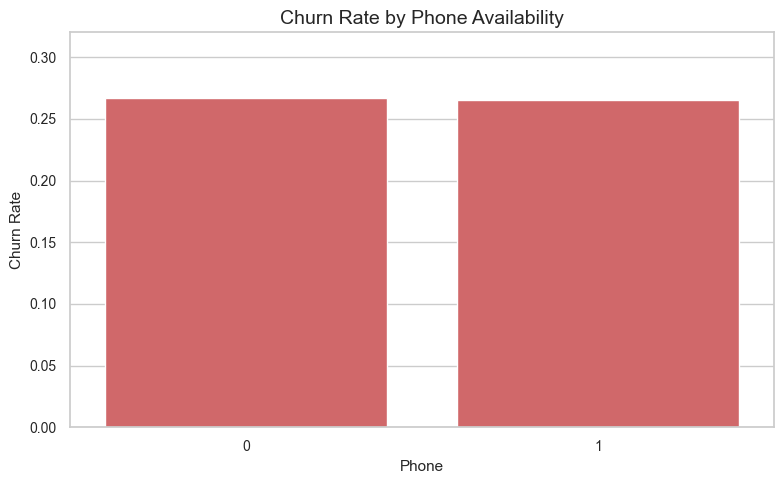

Nhận xét: Giả thuyết được ủng hộ. Nhóm Phone=0 có churn rate cao hơn Phone=1.


In [82]:
if "Phone" in df.columns:
    phone_tbl = compare_churn_for_group(df, "Phone", "Churn Rate by Phone Availability")
    print_binary_hypothesis_conclusion(
        phone_tbl,
        positive_label=0,
        negative_label=1,
        positive_statement="Nhận xét: Giả thuyết được ủng hộ. Nhóm Phone=0 có churn rate cao hơn Phone=1.",
        negative_statement="Nhận xét: Giả thuyết chưa được ủng hộ. Nhóm Phone=0 không có churn rate cao hơn Phone=1.",
    )
else:
    print("Warning: Phone column not found; skipped.")


### 12.2 Khách hàng gần hết hợp đồng có churn cao hơn không?


,feature_value,customer_count,churn_count,churn_rate
0,Ending soon,2207,934,0.4232
1,Not ending soon,1793,127,0.0708


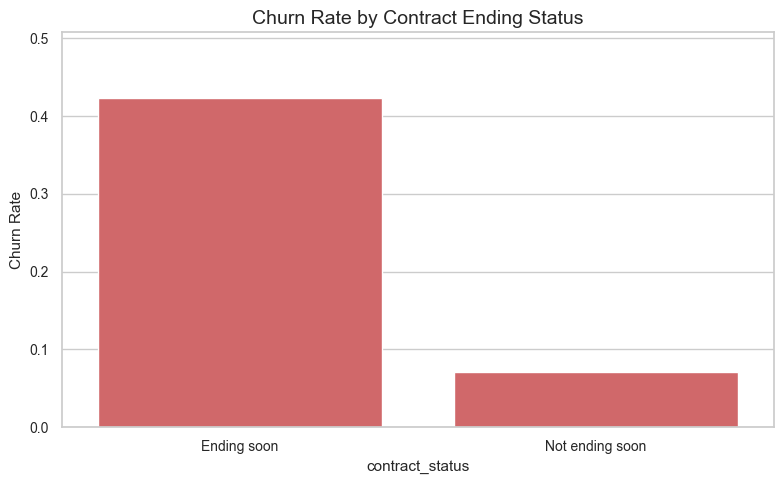

Nhận xét: Giả thuyết được ủng hộ. Khách hàng gần hết hợp đồng có churn rate cao hơn.


In [83]:
if "Month_to_end_contract" in df.columns:
    df_hyp = df.copy()
    df_hyp["contract_status"] = np.where(df_hyp["Month_to_end_contract"] <= 1, "Ending soon", "Not ending soon")
    contract_tbl = compare_churn_for_group(df_hyp, "contract_status", "Churn Rate by Contract Ending Status")
    print_binary_hypothesis_conclusion(
        contract_tbl,
        positive_label="Ending soon",
        negative_label="Not ending soon",
        positive_statement="Nhận xét: Giả thuyết được ủng hộ. Khách hàng gần hết hợp đồng có churn rate cao hơn.",
        negative_statement="Nhận xét: Giả thuyết chưa được ủng hộ. Nhóm gần hết hợp đồng không có churn rate cao hơn.",
    )
else:
    print("Warning: Month_to_end_contract column not found; skipped.")


### 12.3 Khách hàng mới có churn cao hơn không?


,feature_value,customer_count,churn_count,churn_rate
1,New customer,1330,817,0.6143
0,Existing customer,2670,244,0.0914


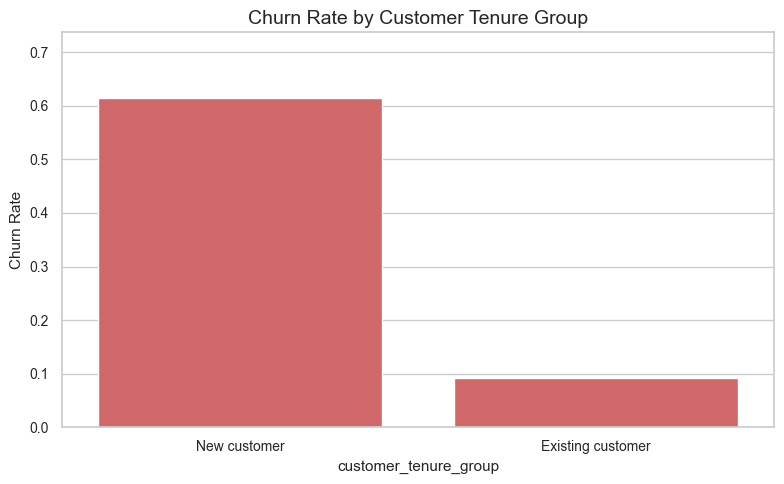

Nhận xét: Giả thuyết được ủng hộ. Khách hàng mới có churn rate cao hơn.


In [84]:
if "Lifetime" in df.columns:
    df_hyp = df.copy()
    df_hyp["customer_tenure_group"] = np.where(df_hyp["Lifetime"] <= 1, "New customer", "Existing customer")
    lifetime_tbl = compare_churn_for_group(df_hyp, "customer_tenure_group", "Churn Rate by Customer Tenure Group")
    print_binary_hypothesis_conclusion(
        lifetime_tbl,
        positive_label="New customer",
        negative_label="Existing customer",
        positive_statement="Nhận xét: Giả thuyết được ủng hộ. Khách hàng mới có churn rate cao hơn.",
        negative_statement="Nhận xét: Giả thuyết chưa được ủng hộ. Khách hàng mới không có churn rate cao hơn.",
    )
else:
    print("Warning: Lifetime column not found; skipped.")


### 12.4 Khách hàng có tần suất đi tập tháng hiện tại thấp có churn cao hơn không?


,feature_value,customer_count,churn_count,churn_rate
1,Low activity,1043,538,0.5158
0,Active,2957,523,0.1769


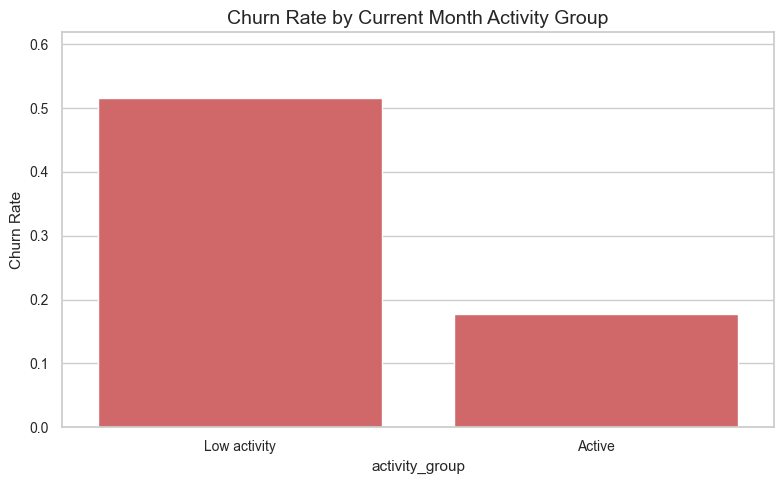

Nhận xét: Giả thuyết được ủng hộ. Khách hàng có tần suất đi tập thấp có churn rate cao hơn.


In [85]:
if "Avg_class_frequency_current_month" in df.columns:
    df_hyp = df.copy()
    df_hyp["activity_group"] = np.where(df_hyp["Avg_class_frequency_current_month"] < 1, "Low activity", "Active")
    activity_tbl = compare_churn_for_group(df_hyp, "activity_group", "Churn Rate by Current Month Activity Group")
    print_binary_hypothesis_conclusion(
        activity_tbl,
        positive_label="Low activity",
        negative_label="Active",
        positive_statement="Nhận xét: Giả thuyết được ủng hộ. Khách hàng có tần suất đi tập thấp có churn rate cao hơn.",
        negative_statement="Nhận xét: Giả thuyết chưa được ủng hộ. Nhóm tần suất thấp không có churn rate cao hơn.",
    )
else:
    print("Warning: Avg_class_frequency_current_month column not found; skipped.")


### 12.5 Khách hàng có group visits có churn thấp hơn không?


,feature_value,customer_count,churn_count,churn_rate
0,0,2351,776,0.3301
1,1,1649,285,0.1728


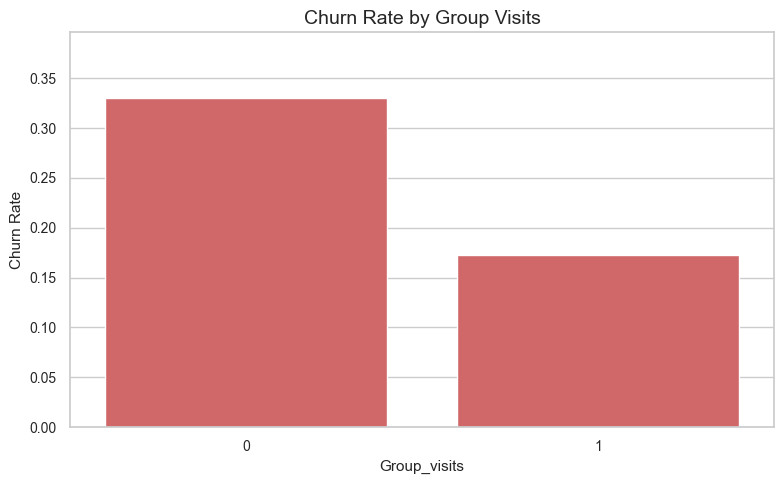

Nhận xét: Giả thuyết được ủng hộ. Khách hàng có group visits có churn rate thấp hơn.


In [86]:
if "Group_visits" in df.columns:
    group_tbl = compare_churn_for_group(df, "Group_visits", "Churn Rate by Group Visits")
    rates = dict(zip(group_tbl["feature_value"], group_tbl["churn_rate"]))
    if 0 in rates and 1 in rates:
        if rates[1] < rates[0]:
            print("Nhận xét: Giả thuyết được ủng hộ. Khách hàng có group visits có churn rate thấp hơn.")
        else:
            print("Nhận xét: Giả thuyết chưa được ủng hộ. Group_visits=1 không có churn rate thấp hơn Group_visits=0.")
    else:
        print("Không đủ nhóm để kết luận giả thuyết này.")
else:
    print("Warning: Group_visits column not found; skipped.")


## 13. Initial insights

Section cuối tổng hợp insight ban đầu từ EDA. Code bên dưới tự động sinh tóm tắt dựa trên dữ liệu hiện tại và các bảng đã tạo trong notebook.


In [87]:
insights = []

n_rows, n_cols = df.shape
missing_total = int(df.isna().sum().sum())
duplicate_count = int(df.duplicated().sum())
churn_rate_overall = df[TARGET_COL].mean() if TARGET_COL in df.columns else np.nan

insights.append(f"Dataset có {n_rows:,} dòng và {n_cols:,} cột.")
insights.append("Dataset has no missing values." if missing_total == 0 else f"Dataset có {missing_total:,} missing values.")
insights.append("Dataset has no duplicate rows." if duplicate_count == 0 else f"Dataset có {duplicate_count:,} duplicate rows ({duplicate_count / n_rows * 100:.2f}%).")
insights.append(f"Tỷ lệ churn tổng thể là {churn_rate_overall * 100:.2f}%.")

if "churn_corr" in globals() and not churn_corr.empty:
    top_corr_features = churn_corr.head(5)["feature"].tolist()
    insights.append("Các feature có correlation tuyệt đối cao nhất với Churn: " + ", ".join(top_corr_features) + ".")

if "top15_churn_groups" in globals() and not top15_churn_groups.empty:
    risky_groups = top15_churn_groups.head(5).apply(lambda r: f"{r['feature']}={r['value']} ({r['churn_rate']:.2%})", axis=1).tolist()
    insights.append("Các nhóm khách hàng có churn rate cao nổi bật: " + "; ".join(risky_groups) + ".")

business_support = []
if "Phone" in df.columns:
    tbl = churn_rate_table(df, "Phone", TARGET_COL)
    rates = dict(zip(tbl["feature_value"], tbl["churn_rate"]))
    if 0 in rates and 1 in rates and rates[0] > rates[1]:
        business_support.append("khách hàng không để lại số điện thoại có churn cao hơn")
if "Month_to_end_contract" in df.columns:
    tmp = df.assign(contract_status=np.where(df["Month_to_end_contract"] <= 1, "Ending soon", "Not ending soon"))
    tbl = churn_rate_table(tmp, "contract_status", TARGET_COL)
    rates = dict(zip(tbl["feature_value"], tbl["churn_rate"]))
    if "Ending soon" in rates and "Not ending soon" in rates and rates["Ending soon"] > rates["Not ending soon"]:
        business_support.append("khách hàng gần hết hợp đồng có churn cao hơn")
if "Lifetime" in df.columns:
    tmp = df.assign(customer_tenure_group=np.where(df["Lifetime"] <= 1, "New customer", "Existing customer"))
    tbl = churn_rate_table(tmp, "customer_tenure_group", TARGET_COL)
    rates = dict(zip(tbl["feature_value"], tbl["churn_rate"]))
    if "New customer" in rates and "Existing customer" in rates and rates["New customer"] > rates["Existing customer"]:
        business_support.append("khách hàng mới có churn cao hơn")
if "Avg_class_frequency_current_month" in df.columns:
    tmp = df.assign(activity_group=np.where(df["Avg_class_frequency_current_month"] < 1, "Low activity", "Active"))
    tbl = churn_rate_table(tmp, "activity_group", TARGET_COL)
    rates = dict(zip(tbl["feature_value"], tbl["churn_rate"]))
    if "Low activity" in rates and "Active" in rates and rates["Low activity"] > rates["Active"]:
        business_support.append("khách hàng có tần suất đi tập thấp có churn cao hơn")
if "Group_visits" in df.columns:
    tbl = churn_rate_table(df, "Group_visits", TARGET_COL)
    rates = dict(zip(tbl["feature_value"], tbl["churn_rate"]))
    if 0 in rates and 1 in rates and rates[1] < rates[0]:
        business_support.append("khách hàng có group visits có churn thấp hơn")

if business_support:
    insights.append("Các giả thuyết business được dữ liệu ủng hộ: " + "; ".join(business_support) + ".")
else:
    insights.append("Chưa có giả thuyết business nào trong danh sách được dữ liệu ủng hộ rõ ràng theo tiêu chí so sánh churn rate đơn giản.")

print("INITIAL INSIGHTS")
print("=" * 80)
for idx, item in enumerate(insights, start=1):
    print(f"{idx}. {item}")

print("Gợi ý cho notebook tiếp theo:")
next_steps = [
    "Preprocessing dữ liệu phù hợp cho modeling.",
    "Train-test split với chiến lược giữ tỷ lệ target nếu cần.",
    "Xây dựng baseline models.",
    "Đánh giá và xử lý imbalance nếu ảnh hưởng đến metric.",
    "Feature engineering dựa trên insight từ EDA.",
]
for idx, item in enumerate(next_steps, start=1):
    print(f"{idx}. {item}")


INITIAL INSIGHTS
1. Dataset có 4,000 dòng và 14 cột.
2. Dataset has no missing values.
3. Dataset has no duplicate rows.
4. Tỷ lệ churn tổng thể là 26.52%.
5. Các feature có correlation tuyệt đối cao nhất với Churn: Lifetime, Avg_class_frequency_current_month, Age, Contract_period, Month_to_end_contract.
6. Các nhóm khách hàng có churn rate cao nổi bật: Contract_period=1 (42.32%); Month_to_end_contract=1.0 (42.32%); Near_Location=0 (39.74%); Partner=0 (33.32%); Group_visits=0 (33.01%).
7. Các giả thuyết business được dữ liệu ủng hộ: khách hàng không để lại số điện thoại có churn cao hơn; khách hàng gần hết hợp đồng có churn cao hơn; khách hàng mới có churn cao hơn; khách hàng có tần suất đi tập thấp có churn cao hơn; khách hàng có group visits có churn thấp hơn.
Gợi ý cho notebook tiếp theo:
1. Preprocessing dữ liệu phù hợp cho modeling.
2. Train-test split với chiến lược giữ tỷ lệ target nếu cần.
3. Xây dựng baseline models.
4. Đánh giá và xử lý imbalance nếu ảnh hưởng đến metric.
5. 

# 14. Statistical Testing

Correlation giúp nhận diện quan hệ tuyến tính giữa feature và target, nhưng chưa đủ để kết luận sự khác biệt giữa nhóm churn và non-churn có ý nghĩa thống kê hay không.

Statistical testing giúp kiểm tra liệu các khác biệt quan sát được có khả năng chỉ do ngẫu nhiên hay không. Tuy nhiên, p-value nhỏ chỉ cho thấy bằng chứng thống kê về association, **không đồng nghĩa với quan hệ nhân quả**.


## 14.1 Import statistical libraries

Import các thư viện thống kê cần thiết cho kiểm định Chi-square, Mann-Whitney U và effect size.


In [88]:
import scipy.stats as stats

try:
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("statsmodels is not installed. This section does not require it, so the notebook will continue.")


statsmodels is not installed. This section does not require it, so the notebook will continue.


## 14.2 Define feature groups

Reuse nhóm feature chính cho statistical testing. Nếu thiếu cột, notebook sẽ bỏ qua an toàn.


In [89]:
stat_binary_discrete_features = safe_existing_columns([
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Group_visits",
    "Contract_period",
])

stat_continuous_features = safe_existing_columns([
    "Age",
    "Lifetime",
    "Avg_additional_charges_total",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
    "Month_to_end_contract",
])

print("Binary/discrete features for statistical testing:", stat_binary_discrete_features)
print("Continuous numeric features for statistical testing:", stat_continuous_features)
print("Target:", TARGET_COL)


Binary/discrete features for statistical testing: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits', 'Contract_period']
Continuous numeric features for statistical testing: ['Age', 'Lifetime', 'Avg_additional_charges_total', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Month_to_end_contract']
Target: Churn


## 14.3 Statistical test for binary/discrete features

Dùng **Chi-square test of independence** để kiểm tra feature dạng binary/discrete có liên quan thống kê tới `Churn` hay không.

Diễn giải:
- p-value nhỏ hơn 0.05: có bằng chứng thống kê rằng feature và churn không độc lập.
- p-value rất nhỏ, ví dụ dưới 0.001: có thể xem là **very strong statistical evidence**.
- Kết quả này không chứng minh causation.


,feature,chi2_statistic,p_value,degrees_of_freedom,significant,evidence
6,Contract_period,653.5552,0.0000,2,True,very strong statistical evidence
5,Group_visits,122.1495,0.0000,1,True,very strong statistical evidence
3,Promo_friends,104.4841,0.0000,1,True,very strong statistical evidence
2,Partner,99.1233,0.0000,1,True,very strong statistical evidence
1,Near_Location,64.8365,0.0000,1,True,very strong statistical evidence
4,Phone,0.0002,0.9890,1,False,not statistically significant
0,gender,0.0001,0.9929,1,False,not statistically significant


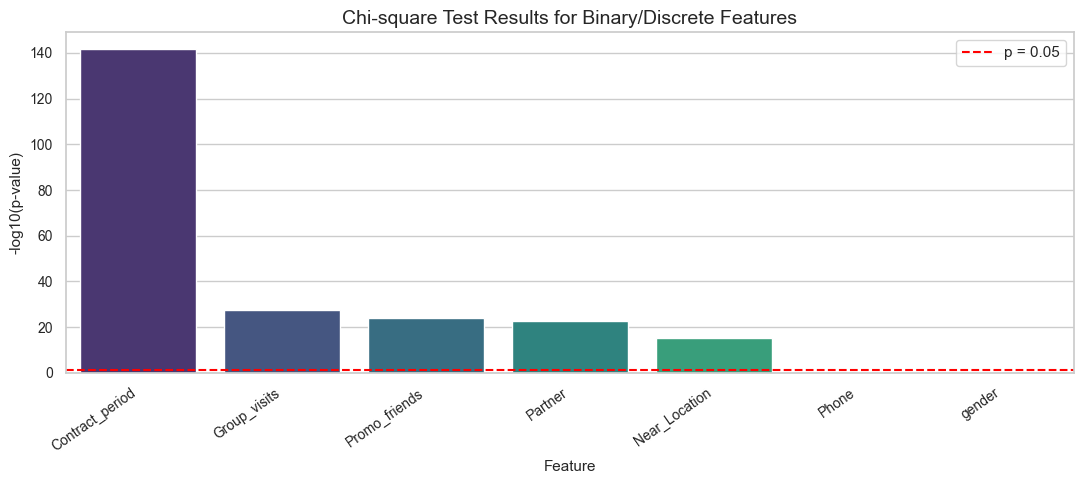

Features with strongest statistical evidence by Chi-square test:


,feature,p_value,evidence
6,Contract_period,0.0000,very strong statistical evidence
5,Group_visits,0.0000,very strong statistical evidence
3,Promo_friends,0.0000,very strong statistical evidence
2,Partner,0.0000,very strong statistical evidence
1,Near_Location,0.0000,very strong statistical evidence


In [90]:
def chi_square_test(data: pd.DataFrame, feature: str, target: str = TARGET_COL) -> dict:
    """Run Chi-square test of independence between a categorical feature and target."""
    if feature not in data.columns or target not in data.columns:
        return {
            "feature": feature,
            "chi2_statistic": np.nan,
            "p_value": np.nan,
            "degrees_of_freedom": np.nan,
            "significant": False,
            "evidence": "missing column",
        }

    contingency_table = pd.crosstab(data[feature], data[target])
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        return {
            "feature": feature,
            "chi2_statistic": np.nan,
            "p_value": np.nan,
            "degrees_of_freedom": np.nan,
            "significant": False,
            "evidence": "insufficient groups",
        }

    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    return {
        "feature": feature,
        "chi2_statistic": chi2_stat,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "significant": p_value < 0.05,
        "evidence": "very strong statistical evidence" if p_value < 0.001 else ("statistically significant" if p_value < 0.05 else "not statistically significant"),
    }


chi_square_results = pd.DataFrame([
    chi_square_test(df, feature, TARGET_COL)
    for feature in stat_binary_discrete_features
]).sort_values("p_value", na_position="last")

display(chi_square_results)

if not chi_square_results.empty:
    plot_data = chi_square_results.dropna(subset=["p_value"]).copy()
    plot_data["minus_log10_p_value"] = -np.log10(plot_data["p_value"].clip(lower=1e-300))

    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_data, x="feature", y="minus_log10_p_value", palette="viridis")
    plt.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1.5, label="p = 0.05")
    plt.title("Chi-square Test Results for Binary/Discrete Features")
    plt.xlabel("Feature")
    plt.ylabel("-log10(p-value)")
    plt.xticks(rotation=35, ha="right")
    plt.legend()
    plt.tight_layout()
    save_fig("stat_chi_square_p_values.png")
    plt.show()

    strongest_discrete = plot_data.sort_values("p_value").head(5)[["feature", "p_value", "evidence"]]
    print("Features with strongest statistical evidence by Chi-square test:")
    display(strongest_discrete)


## 14.4 Statistical test for continuous numeric features

Dùng **Mann-Whitney U test** để kiểm tra numeric features có khác biệt đáng kể giữa hai nhóm `Churn=0` và `Churn=1` hay không.

Lý do dùng Mann-Whitney U:
- Nhiều feature có thể lệch phân phối.
- Không yêu cầu giả định normality như t-test.
- Phù hợp để so sánh hai nhóm độc lập ở mức phân phối/rank.


,feature,statistic,p_value,significant,mean_non_churn,mean_churn,median_non_churn,median_churn
1,Lifetime,"2,737,108.0000",0.0000,True,4.7118,0.9906,4.0000,1.0000
4,Avg_class_frequency_current_month,"2,416,199.0000",0.0000,True,2.0279,1.0445,2.0467,0.9794
0,Age,"2,374,707.5000",0.0000,True,29.9765,26.9896,30.0000,27.0000
5,Month_to_end_contract,"2,295,553.0000",0.0000,True,5.2831,1.6626,6.0000,1.0000
3,Avg_class_frequency_total,"2,075,227.0000",0.0000,True,2.0249,1.4750,2.0433,1.4912
2,Avg_additional_charges_total,"1,949,479.0000",0.0000,True,158.4457,115.0829,149.8812,103.8147


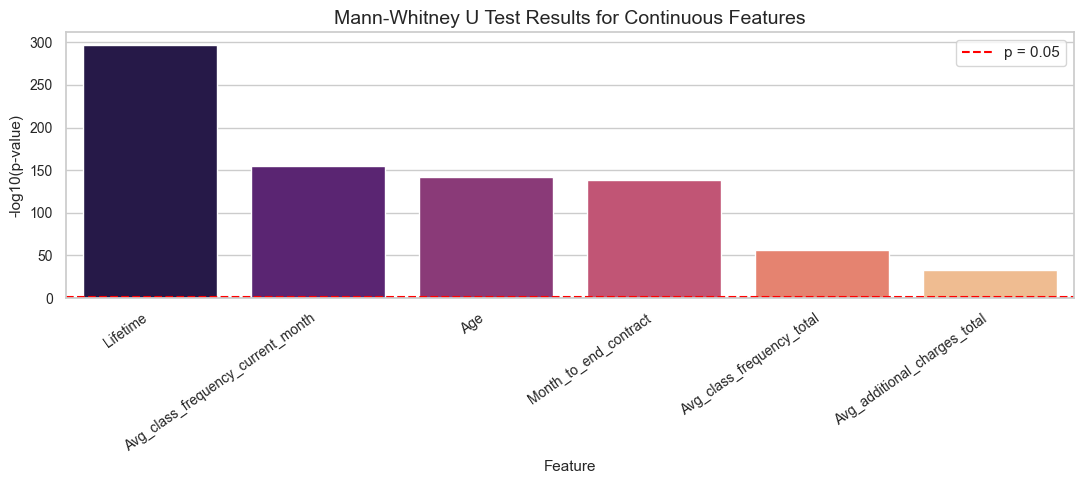

Numeric features with strongest evidence of distribution difference between churn and non-churn:


,feature,p_value,mean_non_churn,mean_churn,median_non_churn,median_churn
1,Lifetime,0.0000,4.7118,0.9906,4.0000,1.0000
4,Avg_class_frequency_current_month,0.0000,2.0279,1.0445,2.0467,0.9794
0,Age,0.0000,29.9765,26.9896,30.0000,27.0000
5,Month_to_end_contract,0.0000,5.2831,1.6626,6.0000,1.0000
3,Avg_class_frequency_total,0.0000,2.0249,1.4750,2.0433,1.4912


In [91]:
def mann_whitney_test(data: pd.DataFrame, feature: str, target: str = TARGET_COL) -> dict:
    """Run Mann-Whitney U test between non-churn and churn groups for a numeric feature."""
    if feature not in data.columns or target not in data.columns:
        return {
            "feature": feature,
            "statistic": np.nan,
            "p_value": np.nan,
            "significant": False,
            "mean_non_churn": np.nan,
            "mean_churn": np.nan,
            "median_non_churn": np.nan,
            "median_churn": np.nan,
        }

    group_non_churn = data.loc[data[target] == 0, feature].dropna()
    group_churn = data.loc[data[target] == 1, feature].dropna()

    if len(group_non_churn) == 0 or len(group_churn) == 0:
        statistic, p_value = np.nan, np.nan
        significant = False
    else:
        statistic, p_value = stats.mannwhitneyu(group_non_churn, group_churn, alternative="two-sided")
        significant = p_value < 0.05

    return {
        "feature": feature,
        "statistic": statistic,
        "p_value": p_value,
        "significant": significant,
        "mean_non_churn": group_non_churn.mean(),
        "mean_churn": group_churn.mean(),
        "median_non_churn": group_non_churn.median(),
        "median_churn": group_churn.median(),
    }


mann_whitney_results = pd.DataFrame([
    mann_whitney_test(df, feature, TARGET_COL)
    for feature in stat_continuous_features
]).sort_values("p_value", na_position="last")

display(mann_whitney_results)

if not mann_whitney_results.empty:
    plot_data = mann_whitney_results.dropna(subset=["p_value"]).copy()
    plot_data["minus_log10_p_value"] = -np.log10(plot_data["p_value"].clip(lower=1e-300))

    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_data, x="feature", y="minus_log10_p_value", palette="magma")
    plt.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1.5, label="p = 0.05")
    plt.title("Mann-Whitney U Test Results for Continuous Features")
    plt.xlabel("Feature")
    plt.ylabel("-log10(p-value)")
    plt.xticks(rotation=35, ha="right")
    plt.legend()
    plt.tight_layout()
    save_fig("stat_mann_whitney_p_values.png")
    plt.show()

    strongest_numeric = plot_data.sort_values("p_value").head(5)[["feature", "p_value", "mean_non_churn", "mean_churn", "median_non_churn", "median_churn"]]
    print("Numeric features with strongest evidence of distribution difference between churn and non-churn:")
    display(strongest_numeric)


## 14.5 Effect size analysis

Statistical significance cho biết khác biệt có đáng tin về mặt thống kê hay không, nhưng không nói rõ khác biệt đó lớn hay nhỏ về mặt thực tế.

Vì vậy, ta tính **Cohen's d** cho numeric features để đánh giá practical significance:
- `< 0.2`: negligible
- `0.2-0.5`: small
- `0.5-0.8`: medium
- `>= 0.8`: large

Dấu của Cohen's d cho biết hướng khác biệt. Ở đây tính theo công thức: mean(churn) - mean(non-churn), chia cho pooled standard deviation.


,feature,cohen_d,abs_cohen_d,effect_size_category
1,Lifetime,-1.1041,1.1041,large
4,Avg_class_frequency_current_month,-1.0250,1.0250,large
0,Age,-1.0023,1.0023,large
5,Month_to_end_contract,-0.9343,0.9343,large
3,Avg_class_frequency_total,-0.5840,0.5840,medium
2,Avg_additional_charges_total,-0.4591,0.4591,small


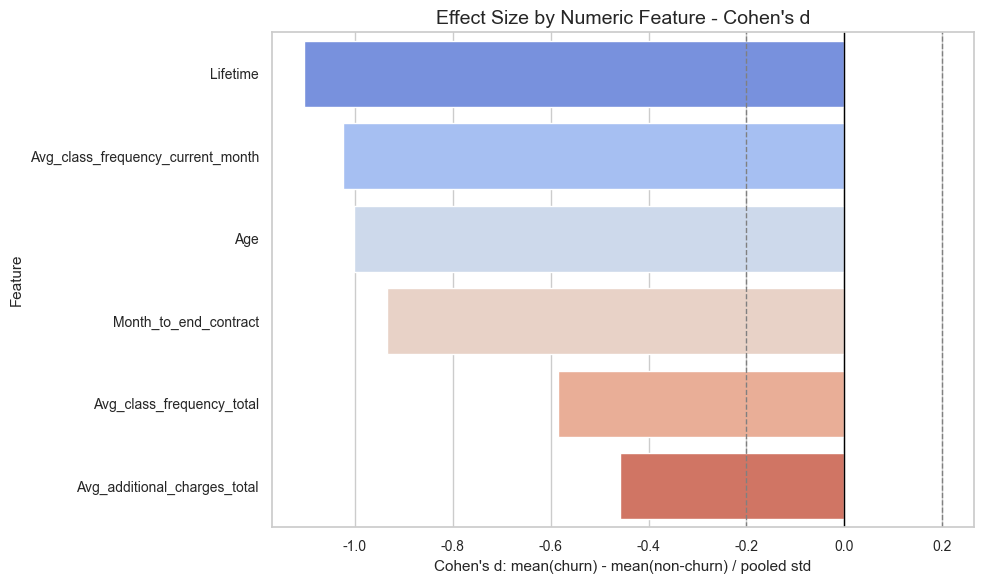

Features with largest practical effect size:


,feature,cohen_d,abs_cohen_d,effect_size_category
1,Lifetime,-1.1041,1.1041,large
4,Avg_class_frequency_current_month,-1.0250,1.0250,large
0,Age,-1.0023,1.0023,large
5,Month_to_end_contract,-0.9343,0.9343,large
3,Avg_class_frequency_total,-0.5840,0.5840,medium


In [92]:
def cohens_d(group1: pd.Series, group2: pd.Series) -> float:
    """Calculate Cohen's d for two independent groups as mean(group2) - mean(group1)."""
    group1 = pd.Series(group1).dropna()
    group2 = pd.Series(group2).dropna()
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_std = np.sqrt(((n1 - 1) * group1.var(ddof=1) + (n2 - 1) * group2.var(ddof=1)) / (n1 + n2 - 2))
    if pooled_std == 0 or pd.isna(pooled_std):
        return np.nan
    return (group2.mean() - group1.mean()) / pooled_std


def effect_size_category(value: float) -> str:
    abs_value = abs(value)
    if pd.isna(abs_value):
        return "undefined"
    if abs_value < 0.2:
        return "negligible"
    if abs_value < 0.5:
        return "small"
    if abs_value < 0.8:
        return "medium"
    return "large"


effect_size_rows = []
for feature in stat_continuous_features:
    non_churn_values = df.loc[df[TARGET_COL] == 0, feature]
    churn_values = df.loc[df[TARGET_COL] == 1, feature]
    d_value = cohens_d(non_churn_values, churn_values)
    effect_size_rows.append({
        "feature": feature,
        "cohen_d": d_value,
        "abs_cohen_d": abs(d_value) if pd.notna(d_value) else np.nan,
        "effect_size_category": effect_size_category(d_value),
    })

effect_size_results = pd.DataFrame(effect_size_rows).sort_values("abs_cohen_d", ascending=False, na_position="last")
display(effect_size_results)

if not effect_size_results.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=effect_size_results, y="feature", x="cohen_d", palette="coolwarm")
    plt.axvline(0, color="black", linewidth=1)
    plt.axvline(0.2, color="gray", linestyle="--", linewidth=1)
    plt.axvline(-0.2, color="gray", linestyle="--", linewidth=1)
    plt.title("Effect Size by Numeric Feature - Cohen's d")
    plt.xlabel("Cohen's d: mean(churn) - mean(non-churn) / pooled std")
    plt.ylabel("Feature")
    plt.tight_layout()
    save_fig("stat_cohens_d_effect_size.png")
    plt.show()

    print("Features with largest practical effect size:")
    display(effect_size_results.head(5))


# 15. Outlier Analysis

Outlier có thể là dữ liệu lỗi, nhưng cũng có thể phản ánh hành vi khách hàng đặc biệt. Ví dụ khách hàng chi tiêu rất cao có thể là premium members, khách hàng có tần suất tập rất cao có thể là nhóm fitness enthusiasts.

Vì vậy, notebook này **không xóa outlier**. Mục tiêu là hiểu mức độ xuất hiện outlier, xem outlier có liên quan tới churn hay không, và chuẩn bị insight cho feature engineering/modeling.


## 15.1 Numeric distribution review

Review lại phân phối các numeric features quan trọng bằng histogram và boxplot, kèm skewness, tail direction và extreme values.


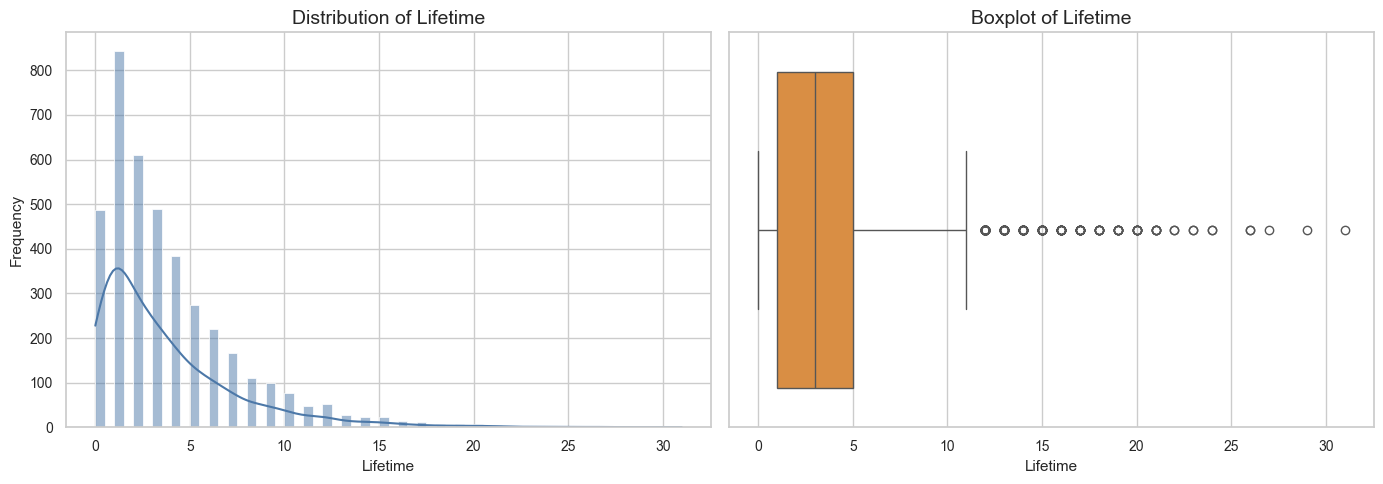

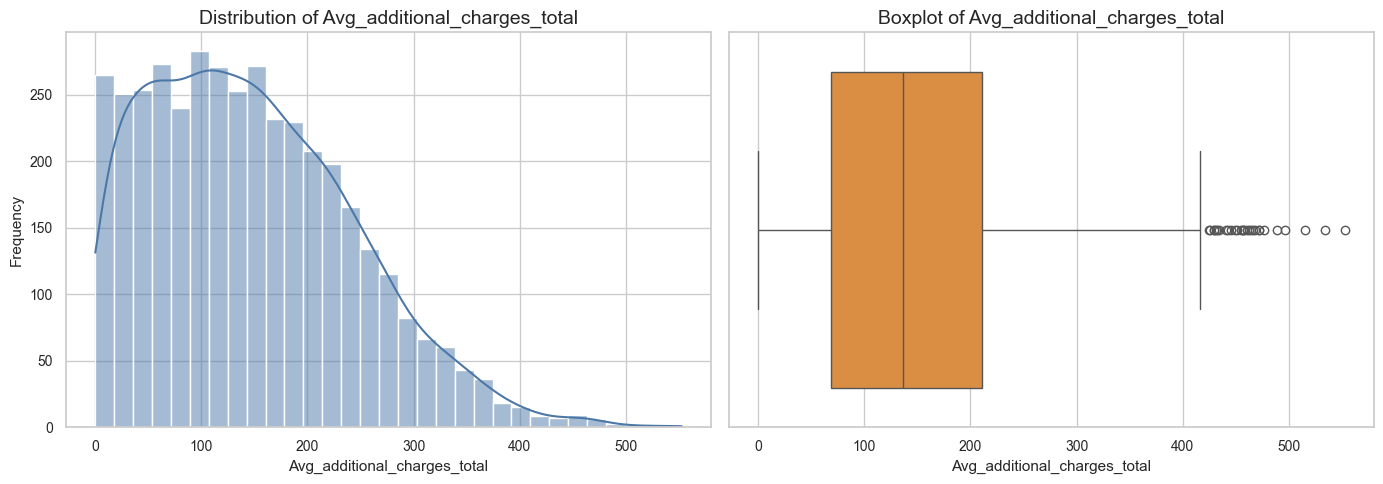

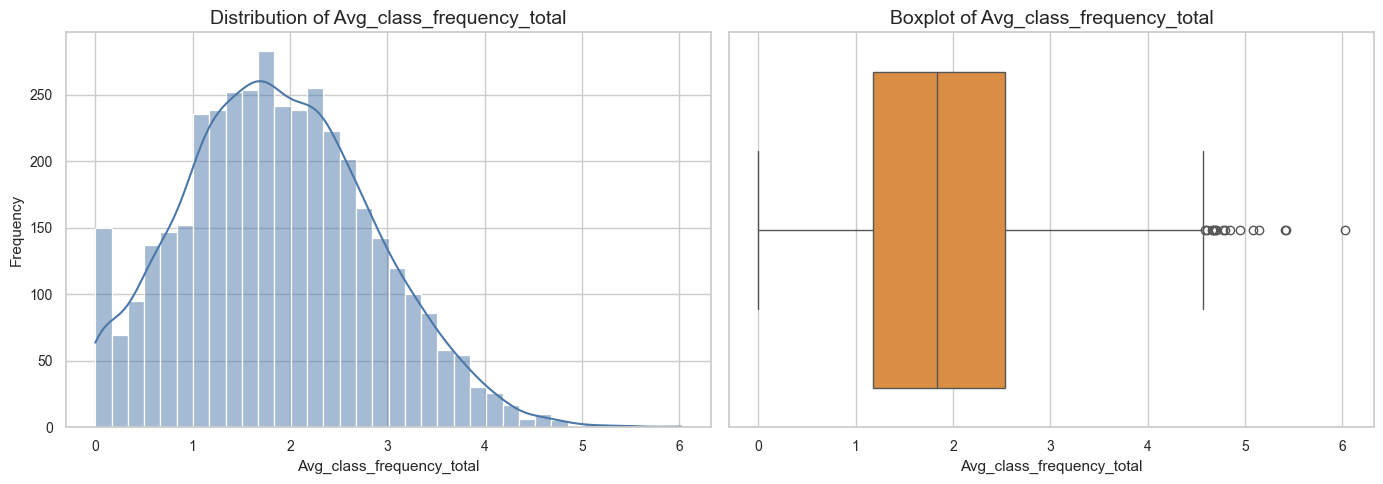

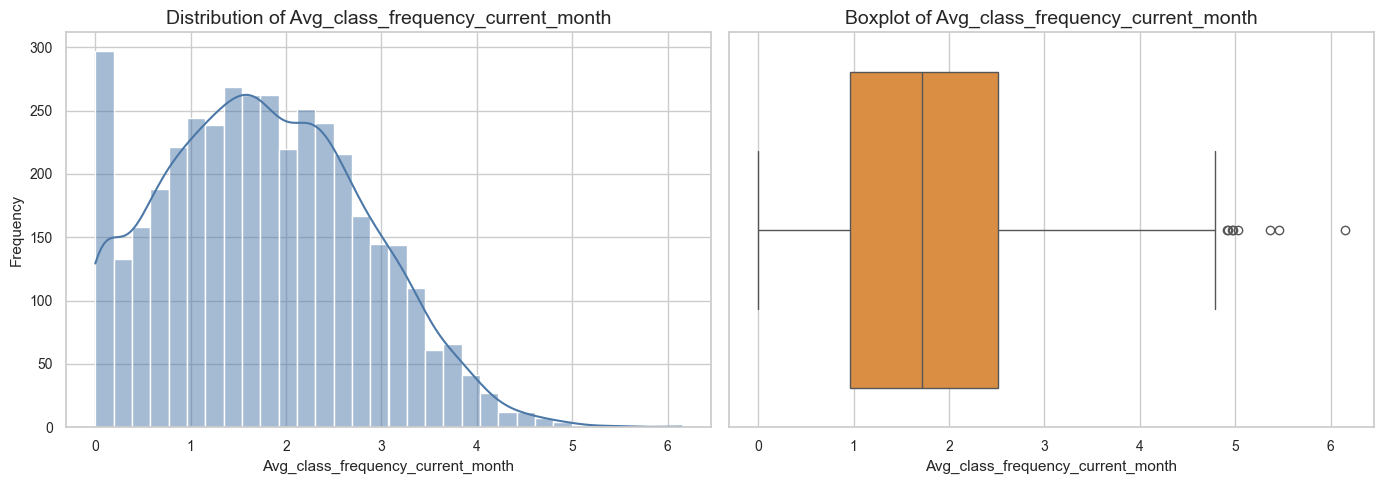

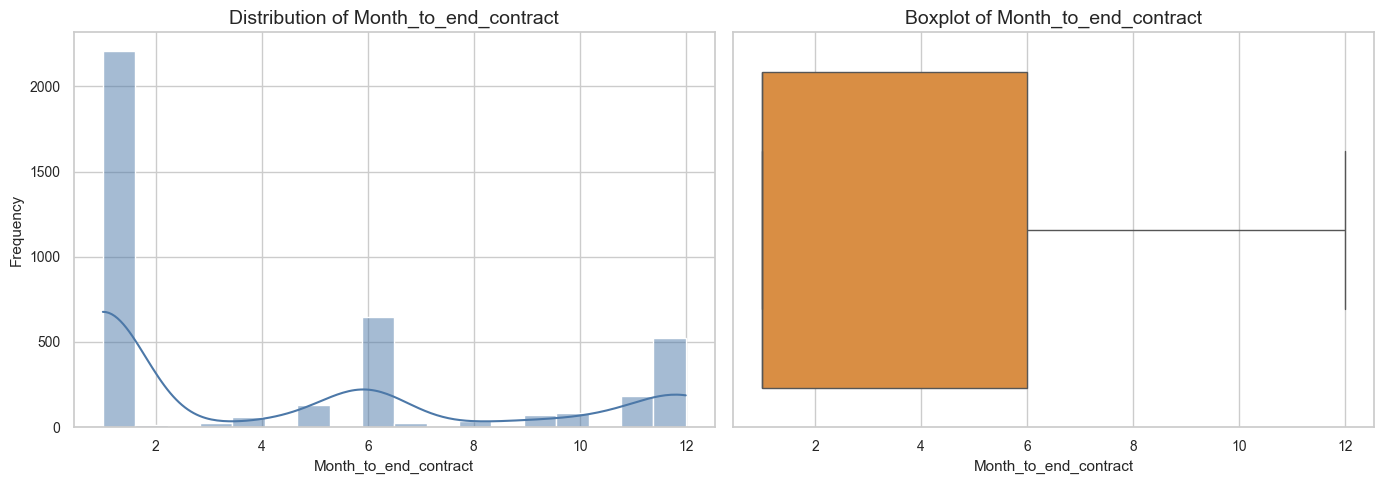

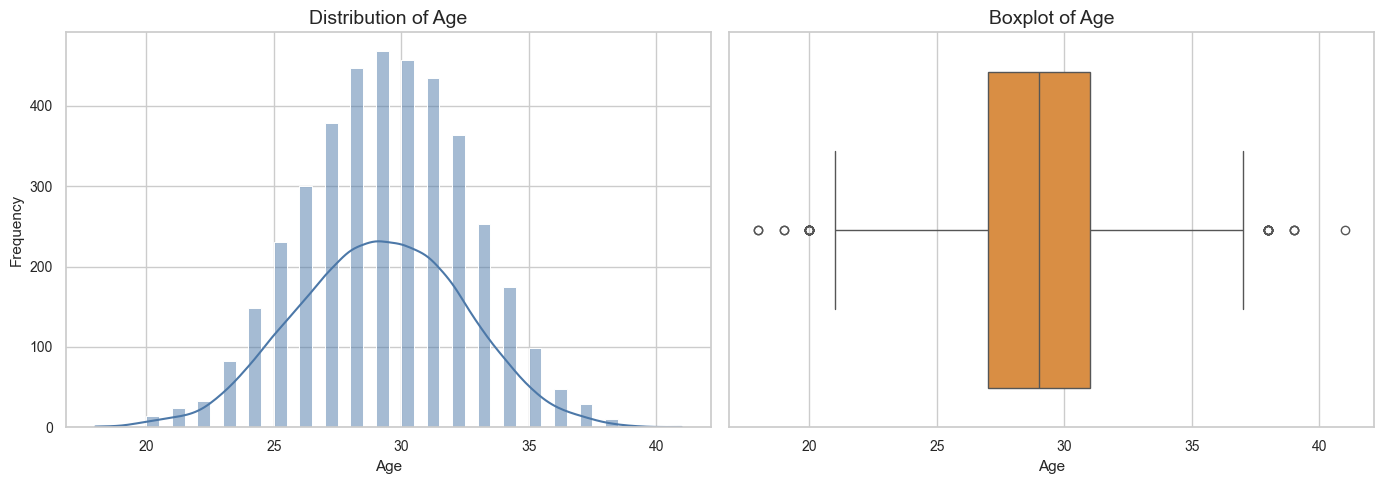

,feature,skewness,tail,min,p01,median,p99,max
0,Lifetime,1.9275,strong right tail,0.0000,0.0000,3.0000,17.0000,31.0000
1,Avg_additional_charges_total,0.6169,moderate right tail,0.1482,2.8167,136.2202,400.9961,552.5907
2,Avg_class_frequency_total,0.2530,roughly symmetric,0.0000,0.0000,1.8328,4.1976,6.0237
3,Avg_class_frequency_current_month,0.2621,roughly symmetric,0.0000,0.0000,1.7196,4.1858,6.1468
4,Month_to_end_contract,0.8078,moderate right tail,1.0000,1.0000,1.0000,12.0000,12.0000
5,Age,-0.0603,roughly symmetric,18.0000,21.0000,29.0000,37.0000,41.0000


In [93]:
outlier_numeric_features = safe_existing_columns([
    "Lifetime",
    "Avg_additional_charges_total",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
    "Month_to_end_contract",
    "Age",
])


def describe_numeric_distribution(data: pd.DataFrame, feature: str) -> dict:
    values = data[feature].dropna()
    skew_value = values.skew()
    if skew_value > 1:
        tail_comment = "strong right tail"
    elif skew_value > 0.5:
        tail_comment = "moderate right tail"
    elif skew_value < -1:
        tail_comment = "strong left tail"
    elif skew_value < -0.5:
        tail_comment = "moderate left tail"
    else:
        tail_comment = "roughly symmetric"

    return {
        "feature": feature,
        "skewness": skew_value,
        "tail": tail_comment,
        "min": values.min(),
        "p01": values.quantile(0.01),
        "median": values.median(),
        "p99": values.quantile(0.99),
        "max": values.max(),
    }


distribution_review_rows = []
for feature in outlier_numeric_features:
    distribution_review_rows.append(describe_numeric_distribution(df, feature))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df[feature].dropna(), kde=True, ax=axes[0], color="#4C78A8")
    axes[0].set_title(f"Distribution of {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Frequency")

    sns.boxplot(x=df[feature], ax=axes[1], color="#F28E2B")
    axes[1].set_title(f"Boxplot of {feature}")
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel("")

    plt.tight_layout()
    save_fig(f"outlier_distribution_review_{feature}.png")
    plt.show()

numeric_distribution_review = pd.DataFrame(distribution_review_rows)
display(numeric_distribution_review)


## 15.2 IQR-based outlier detection

Dùng quy tắc IQR để phát hiện outlier:
- Lower bound = Q1 - 1.5 * IQR
- Upper bound = Q3 + 1.5 * IQR

Đây là rule thống kê đơn giản để nhận diện giá trị cực trị, không phải quyết định xóa dữ liệu.


In [94]:
def detect_outliers_iqr(data: pd.DataFrame, column: str) -> dict:
    """Detect outliers using the IQR rule and return summary statistics."""
    values = data[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    outlier_count = int(outlier_mask.sum())
    outlier_percentage = outlier_count / len(data) * 100 if len(data) > 0 else 0

    return {
        "feature": column,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    }


outlier_summary = pd.DataFrame([
    detect_outliers_iqr(df, feature)
    for feature in outlier_numeric_features
]).sort_values("outlier_percentage", ascending=False)

display(outlier_summary)


,feature,outlier_count,outlier_percentage,lower_bound,upper_bound
0,Lifetime,192,4.8000,-5.0000,11.0000
5,Age,32,0.8000,21.0000,37.0000
1,Avg_additional_charges_total,29,0.7250,-144.2524,424.0708
2,Avg_class_frequency_total,16,0.4000,-0.8519,4.5689
3,Avg_class_frequency_current_month,8,0.2000,-1.3580,4.8313
4,Month_to_end_contract,0,0.0000,-6.5000,13.5000


## 15.3 Visualize outliers vs churn

Vẽ stripplot để quan sát giá trị cực trị có tập trung nhiều hơn ở nhóm churn hay non-churn hay không.


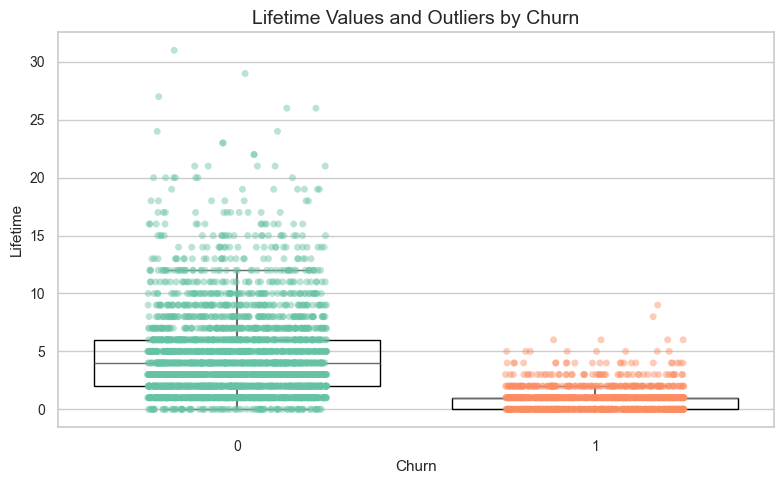

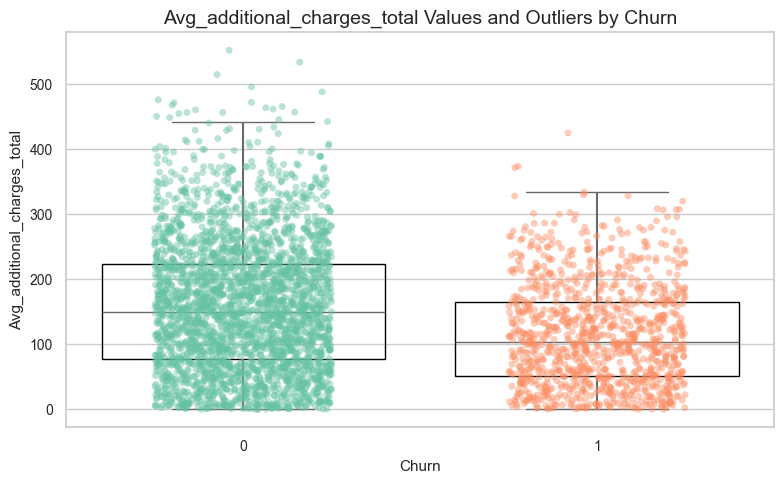

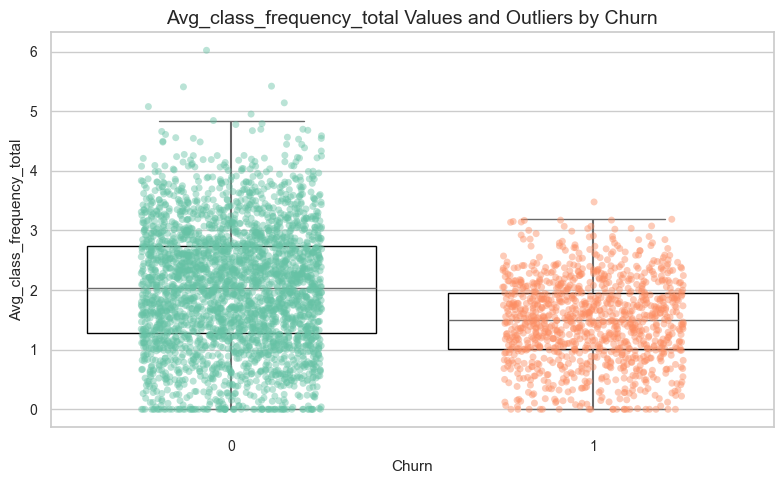

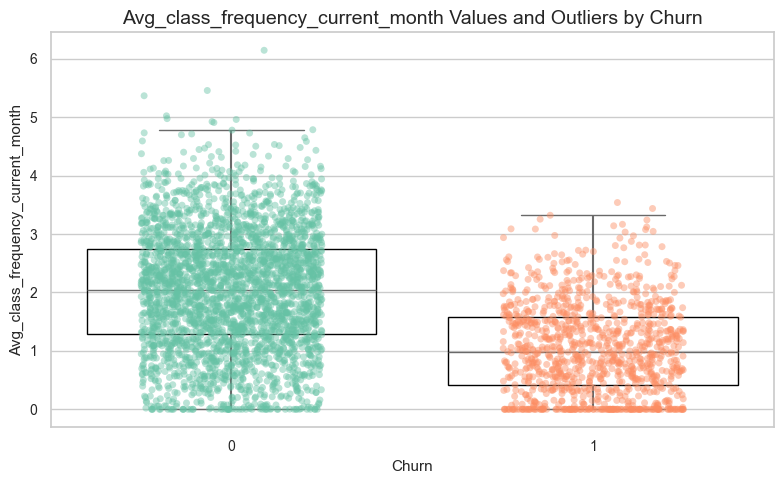

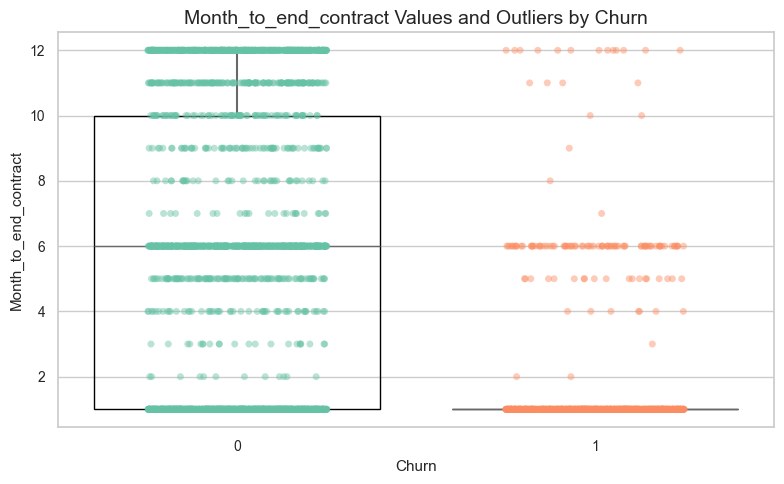

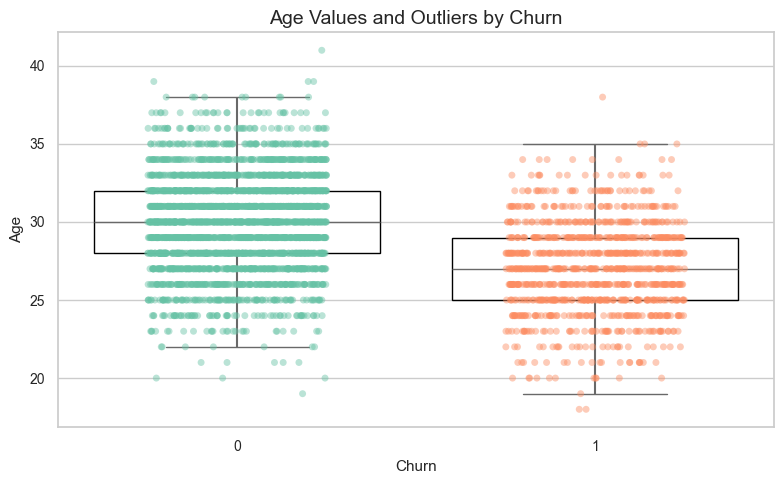

In [95]:
for feature in outlier_numeric_features:
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=df, x=TARGET_COL, y=feature, jitter=0.25, alpha=0.45, palette="Set2")
    sns.boxplot(data=df, x=TARGET_COL, y=feature, showcaps=True, boxprops={"facecolor": "none", "edgecolor": "black"}, showfliers=False, whiskerprops={"linewidth": 1.5}, ax=plt.gca())
    plt.title(f"{feature} Values and Outliers by Churn")
    plt.xlabel("Churn")
    plt.ylabel(feature)
    plt.tight_layout()
    save_fig(f"outliers_vs_churn_{feature}.png")
    plt.show()


## 15.4 Business interpretation of outliers

Outlier cần được diễn giải theo business context trước khi quyết định xử lý. Các nhận xét dưới đây là hypothesis/interpretation ban đầu, không phải kết luận dữ liệu lỗi.


In [96]:
business_outlier_interpretation = {
    "Lifetime": "Khách hàng có Lifetime rất cao có thể là loyal customers. Đây thường là tín hiệu retention tốt, không nên xem là lỗi nếu giá trị hợp lý theo thời gian vận hành của gym.",
    "Avg_additional_charges_total": "Khách có additional charges rất cao có thể là premium members hoặc khách mua thêm nhiều dịch vụ. Nhóm này có thể có hành vi khác biệt và đáng cân nhắc cho feature engineering.",
    "Avg_class_frequency_total": "Tần suất tập trung bình toàn kỳ rất cao có thể phản ánh nhóm tập luyện nghiêm túc. Nếu hợp lý về mặt business, đây là tín hiệu engagement mạnh.",
    "Avg_class_frequency_current_month": "Attendance tháng hiện tại cực cao có thể là fitness enthusiasts; attendance rất thấp có thể là cảnh báo churn sớm.",
    "Month_to_end_contract": "Giá trị cao/thấp phản ánh trạng thái hợp đồng. Gần hết hợp đồng thường có business meaning trực tiếp với churn risk.",
    "Age": "Tuổi quá cao hoặc quá thấp cần kiểm tra tính hợp lý, nhưng chưa nên xem là lỗi nếu nằm trong phân khúc khách hàng thực tế của gym.",
}

for feature in outlier_numeric_features:
    print(f"{feature}: {business_outlier_interpretation.get(feature, 'Cần kiểm tra thêm business context trước khi xử lý outlier.')}")


Lifetime: Khách hàng có Lifetime rất cao có thể là loyal customers. Đây thường là tín hiệu retention tốt, không nên xem là lỗi nếu giá trị hợp lý theo thời gian vận hành của gym.
Avg_additional_charges_total: Khách có additional charges rất cao có thể là premium members hoặc khách mua thêm nhiều dịch vụ. Nhóm này có thể có hành vi khác biệt và đáng cân nhắc cho feature engineering.
Avg_class_frequency_total: Tần suất tập trung bình toàn kỳ rất cao có thể phản ánh nhóm tập luyện nghiêm túc. Nếu hợp lý về mặt business, đây là tín hiệu engagement mạnh.
Avg_class_frequency_current_month: Attendance tháng hiện tại cực cao có thể là fitness enthusiasts; attendance rất thấp có thể là cảnh báo churn sớm.
Month_to_end_contract: Giá trị cao/thấp phản ánh trạng thái hợp đồng. Gần hết hợp đồng thường có business meaning trực tiếp với churn risk.
Age: Tuổi quá cao hoặc quá thấp cần kiểm tra tính hợp lý, nhưng chưa nên xem là lỗi nếu nằm trong phân khúc khách hàng thực tế của gym.


## 15.5 Log transformation suggestions

Tự động kiểm tra skewness. Nếu `abs(skewness) > 1`, đề xuất cân nhắc `log1p` transform trong notebook preprocessing/modeling sau.

Skewed features có thể ảnh hưởng nhiều tới linear models như Logistic Regression. Tree-based models như RandomForest, XGBoost, CatBoost thường ít nhạy hơn, nhưng transformation vẫn có thể hữu ích trong một số pipeline.


In [97]:
log_transform_suggestions = []
for feature in outlier_numeric_features:
    skew_value = df[feature].dropna().skew()
    log_transform_suggestions.append({
        "feature": feature,
        "skewness": skew_value,
        "recommended_transform": "log1p" if abs(skew_value) > 1 else "none",
    })

log_transform_suggestions = pd.DataFrame(log_transform_suggestions).sort_values("skewness", key=lambda s: s.abs(), ascending=False)
display(log_transform_suggestions)

recommended_features = log_transform_suggestions.loc[log_transform_suggestions["recommended_transform"] == "log1p", "feature"].tolist()
if recommended_features:
    print("Features recommended for log1p consideration:", recommended_features)
else:
    print("No numeric feature has |skewness| > 1 based on the current rule.")


,feature,skewness,recommended_transform
0,Lifetime,1.9275,log1p
4,Month_to_end_contract,0.8078,none
1,Avg_additional_charges_total,0.6169,none
3,Avg_class_frequency_current_month,0.2621,none
2,Avg_class_frequency_total,0.2530,none
5,Age,-0.0603,none


Features recommended for log1p consideration: ['Lifetime']


# 16. Final Statistical Insights

Section này tổng hợp insight thống kê cuối cùng để chuẩn bị cho feature engineering và modeling.


In [98]:
final_statistical_insights = []

if "chi_square_results" in globals() and not chi_square_results.empty:
    significant_discrete = chi_square_results.loc[chi_square_results["significant"] == True, "feature"].tolist()
    strongest_discrete_feature = chi_square_results.dropna(subset=["p_value"]).iloc[0]["feature"] if chi_square_results["p_value"].notna().any() else None
    final_statistical_insights.append(
        "Binary/discrete features có statistical significance: " + (", ".join(significant_discrete) if significant_discrete else "không có feature nào dưới ngưỡng p < 0.05") + "."
    )
    if strongest_discrete_feature:
        final_statistical_insights.append(f"Discrete feature có bằng chứng thống kê mạnh nhất theo p-value: {strongest_discrete_feature}.")

if "mann_whitney_results" in globals() and not mann_whitney_results.empty:
    significant_numeric = mann_whitney_results.loc[mann_whitney_results["significant"] == True, "feature"].tolist()
    strongest_numeric_feature = mann_whitney_results.dropna(subset=["p_value"]).iloc[0]["feature"] if mann_whitney_results["p_value"].notna().any() else None
    final_statistical_insights.append(
        "Numeric features có khác biệt đáng kể giữa churn/non-churn: " + (", ".join(significant_numeric) if significant_numeric else "không có feature nào dưới ngưỡng p < 0.05") + "."
    )
    if strongest_numeric_feature:
        final_statistical_insights.append(f"Numeric feature có statistical evidence mạnh nhất: {strongest_numeric_feature}.")

if "effect_size_results" in globals() and not effect_size_results.empty:
    largest_effect = effect_size_results.dropna(subset=["abs_cohen_d"]).head(1)
    if not largest_effect.empty:
        row = largest_effect.iloc[0]
        final_statistical_insights.append(
            f"Feature có effect size lớn nhất: {row['feature']} với Cohen's d = {row['cohen_d']:.3f} ({row['effect_size_category']})."
        )

priority_features = []
for feature in ["Lifetime", "Avg_class_frequency_current_month", "Month_to_end_contract", "Contract_period"]:
    evidence_parts = []
    if "mann_whitney_results" in globals() and feature in mann_whitney_results["feature"].values:
        p_value = mann_whitney_results.loc[mann_whitney_results["feature"] == feature, "p_value"].iloc[0]
        if pd.notna(p_value) and p_value < 0.05:
            evidence_parts.append(f"Mann-Whitney p={p_value:.2e}")
    if "chi_square_results" in globals() and feature in chi_square_results["feature"].values:
        p_value = chi_square_results.loc[chi_square_results["feature"] == feature, "p_value"].iloc[0]
        if pd.notna(p_value) and p_value < 0.05:
            evidence_parts.append(f"Chi-square p={p_value:.2e}")
    if "effect_size_results" in globals() and feature in effect_size_results["feature"].values:
        d_value = effect_size_results.loc[effect_size_results["feature"] == feature, "cohen_d"].iloc[0]
        category = effect_size_results.loc[effect_size_results["feature"] == feature, "effect_size_category"].iloc[0]
        if pd.notna(d_value):
            evidence_parts.append(f"Cohen's d={d_value:.2f} ({category})")
    if evidence_parts:
        priority_features.append(f"{feature}: " + "; ".join(evidence_parts))

if priority_features:
    final_statistical_insights.append("Các feature ưu tiên đặc biệt cho modeling/feature engineering: " + " | ".join(priority_features) + ".")

if "outlier_summary" in globals() and not outlier_summary.empty:
    top_outlier_features = outlier_summary.head(3).apply(lambda r: f"{r['feature']} ({r['outlier_percentage']:.2f}%)", axis=1).tolist()
    final_statistical_insights.append("Outlier xuất hiện nhiều nhất ở: " + ", ".join(top_outlier_features) + ". Không nên xóa outlier nếu chưa có bằng chứng là dữ liệu lỗi.")

if "log_transform_suggestions" in globals() and not log_transform_suggestions.empty:
    log_features = log_transform_suggestions.loc[log_transform_suggestions["recommended_transform"] == "log1p", "feature"].tolist()
    if log_features:
        final_statistical_insights.append("Nên cân nhắc log1p transform trong notebook preprocessing cho: " + ", ".join(log_features) + ".")
    else:
        final_statistical_insights.append("Theo rule |skewness| > 1, chưa có feature nào bắt buộc cần log transform.")

predictive_candidates = []
if "mann_whitney_results" in globals() and not mann_whitney_results.empty:
    predictive_candidates.extend(mann_whitney_results.dropna(subset=["p_value"]).head(5)["feature"].tolist())
if "chi_square_results" in globals() and not chi_square_results.empty:
    predictive_candidates.extend(chi_square_results.dropna(subset=["p_value"]).head(5)["feature"].tolist())
predictive_candidates = list(dict.fromkeys(predictive_candidates))
if predictive_candidates:
    final_statistical_insights.append("Các feature có vẻ predictive nhất cho churn theo EDA thống kê: " + ", ".join(predictive_candidates) + ".")

print("FINAL STATISTICAL INSIGHTS")
print("=" * 80)
for idx, insight in enumerate(final_statistical_insights, start=1):
    print(f"{idx}. {insight}")

print("Modeling direction:")
print("Dataset có tín hiệu churn khá mạnh và nhiều feature có ý nghĩa business. Dữ liệu phù hợp để thử Logistic Regression, RandomForest, XGBoost, CatBoost và dùng SHAP explainability ở các notebook tiếp theo.")


FINAL STATISTICAL INSIGHTS
1. Binary/discrete features có statistical significance: Contract_period, Group_visits, Promo_friends, Partner, Near_Location.
2. Discrete feature có bằng chứng thống kê mạnh nhất theo p-value: Contract_period.
3. Numeric features có khác biệt đáng kể giữa churn/non-churn: Lifetime, Avg_class_frequency_current_month, Age, Month_to_end_contract, Avg_class_frequency_total, Avg_additional_charges_total.
4. Numeric feature có statistical evidence mạnh nhất: Lifetime.
5. Feature có effect size lớn nhất: Lifetime với Cohen's d = -1.104 (large).
6. Các feature ưu tiên đặc biệt cho modeling/feature engineering: Lifetime: Mann-Whitney p=1.58e-297; Cohen's d=-1.10 (large) | Avg_class_frequency_current_month: Mann-Whitney p=1.11e-155; Cohen's d=-1.03 (large) | Month_to_end_contract: Mann-Whitney p=1.92e-139; Cohen's d=-0.93 (large) | Contract_period: Chi-square p=1.21e-142.
7. Outlier xuất hiện nhiều nhất ở: Lifetime (4.80%), Age (0.80%), Avg_additional_charges_total (0